In [16]:
#!/usr/bin/env python3
"""
FIXED: Rename Myeloid Clusters and Create Paper Names Column

Load single cell data, rename specific myeloid clusters, 
and save with new 'paper_names' column.
"""

import pandas as pd
import scanpy as sc
import numpy as np

def rename_myeloid_clusters_and_save_fixed():
    """
    Rename myeloid clusters and create paper_names column - FIXED for categorical
    """
    print("="*80)
    print("RENAMING MYELOID CLUSTERS AND CREATING PAPER NAMES - FIXED")
    print("="*80)
    
    # Define the rename dictionary
    rename_dict = {
        'Myeloid_Macrophage': 'Myeloid_Mac-A',
        'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
        'Myeloid_moDC': 'Myeloid_moDC_A',
        'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
        'Myeloid_marginalzone': 'Myeloid_Mac-F480',
        'Myeloid_migratory': 'Myeloid_MigDC',
        'Myeloid_DC2': 'Myeloid_cDC2',
        'Myeloid_cDC1': 'Myeloid_cDC1',
        'Myeloid_monocyte': 'Myeloid_Monocyte',
        'Myeloid_pDC': 'Myeloid_pDC'
    }
    
    try:
        # Load the single cell data
        print("Loading single cell data...")
        input_path = "/Users/yashkulkarni/cellxgene_data/processed_deconvolution_sc_spleen_240713_fixed_full_data.h5ad"
        adata = sc.read_h5ad(input_path)
        
        print(f"Loaded data: {adata.shape[0]} cells, {adata.shape[1]} genes")
        
        # Check if the celltype column exists (correct name: 'celltypes_redo')
        celltype_col = 'celltypes_redo'
        if celltype_col not in adata.obs.columns:
            print(f"❌ Error: '{celltype_col}' column not found!")
            print("Available columns:")
            for col in adata.obs.columns:
                print(f"  - {col}")
            return
        
        # Show current cell types
        print(f"\nCurrent cell types in '{celltype_col}':")
        current_types = adata.obs[celltype_col].value_counts()
        print(current_types.to_string())
        
        # Check which types will be renamed
        print(f"\nTypes to be renamed:")
        rename_count = 0
        for old_name, new_name in rename_dict.items():
            if old_name in adata.obs[celltype_col].values:
                n_cells = np.sum(adata.obs[celltype_col] == old_name)
                print(f"  {old_name} → {new_name} ({n_cells} cells)")
                rename_count += 1
            else:
                print(f"  ⚠️  {old_name} → {new_name} (NOT FOUND)")
        
        print(f"\nWill rename {rename_count} cell types out of {len(rename_dict)} requested")
        
        # FIXED: Create the new 'paper_names' column by converting to string first
        print(f"\nCreating 'paper_names' column...")
        
        # Convert categorical to string to avoid category restrictions
        print("  Converting categorical to string...")
        adata.obs['paper_names'] = adata.obs[celltype_col].astype(str)
        
        # Apply the renaming on the string version
        print("  Applying renaming...")
        for old_name, new_name in rename_dict.items():
            if old_name in adata.obs['paper_names'].values:
                mask = adata.obs['paper_names'] == old_name
                n_renamed = np.sum(mask)
                adata.obs.loc[mask, 'paper_names'] = new_name
                print(f"    Renamed {n_renamed} cells: {old_name} → {new_name}")
        
        # Convert back to categorical for efficiency
        print("  Converting back to categorical...")
        adata.obs['paper_names'] = pd.Categorical(adata.obs['paper_names'])
        
        # Show the new cell type distribution
        print(f"\nNew cell types in 'paper_names':")
        new_types = adata.obs['paper_names'].value_counts()
        print(new_types.to_string())
        
        # Compare before and after
        print(f"\nSUMMARY COMPARISON:")
        print(f"Original '{celltype_col}': {len(current_types)} unique types")
        print(f"New 'paper_names': {len(new_types)} unique types")
        
        # Show what changed
        print(f"\nCHANGES MADE:")
        unchanged_types = set(current_types.index) - set(rename_dict.keys())
        renamed_types = set(rename_dict.keys()) & set(current_types.index)
        
        print(f"  Unchanged types: {len(unchanged_types)}")
        print(f"  Renamed types: {len(renamed_types)}")
        
        if len(renamed_types) > 0:
            print(f"\nRenamed types:")
            for old_type in renamed_types:
                new_type = rename_dict[old_type]
                n_cells = current_types[old_type]
                print(f"  {old_type} → {new_type} ({n_cells} cells)")
        
        # Verify the data types
        print(f"\nData types:")
        print(f"  {celltype_col}: {adata.obs[celltype_col].dtype}")
        print(f"  paper_names: {adata.obs['paper_names'].dtype}")
        
        # Save the updated data
        output_path = "/Users/yashkulkarni/cellxgene_data/sc_spleen_072225.h5ad"
        print(f"\nSaving updated data to: {output_path}")
        adata.write_h5ad(output_path)
        
        print(f"\n" + "="*80)
        print("✅ SUCCESS!")
        print("="*80)
        print(f"Files:")
        print(f"  Input:  {input_path}")
        print(f"  Output: {output_path}")
        print(f"\nColumns:")
        print(f"  '{celltype_col}': Original cell type names")
        print(f"  'paper_names': New names with myeloid clusters renamed")
        print(f"\nData shape: {adata.shape[0]} cells × {adata.shape[1]} genes")
        
        # Create a summary table
        comparison_data = []
        for cell_type in sorted(set(adata.obs[celltype_col].unique()) | set(adata.obs['paper_names'].unique())):
            original_count = np.sum(adata.obs[celltype_col] == cell_type)
            
            # Find what this became in paper_names
            if cell_type in rename_dict:
                new_name = rename_dict[cell_type]
                new_count = np.sum(adata.obs['paper_names'] == new_name)
                status = "RENAMED"
            else:
                new_name = cell_type
                new_count = np.sum(adata.obs['paper_names'] == cell_type)
                status = "UNCHANGED"
            
            if original_count > 0:  # Only show types that existed in original
                comparison_data.append({
                    'original_name': cell_type,
                    'paper_name': new_name,
                    'n_cells': original_count,
                    'status': status
                })
        
        comparison_df = pd.DataFrame(comparison_data)
        comparison_df = comparison_df.sort_values('n_cells', ascending=False)
        
        print(f"\nDETAILED COMPARISON:")
        print(comparison_df.to_string(index=False))
        
        # Save the comparison
        comparison_df.to_csv("myeloid_renaming_summary.csv", index=False)
        print(f"\nComparison table saved to: myeloid_renaming_summary.csv")
        
        return adata
        
    except Exception as e:
        print(f"❌ Error: {e}")
        import traceback
        traceback.print_exc()

# Run the FIXED renaming
adata = rename_myeloid_clusters_and_save_fixed()

RENAMING MYELOID CLUSTERS AND CREATING PAPER NAMES - FIXED
Loading single cell data...
Loaded data: 60686 cells, 32984 genes

Current cell types in 'celltypes_redo':
celltypes_redo
Bcell_naive                     9369
CD4-Tcell_naive                 6098
CD8-Tcell_naive                 5569
Bcell_early                     4284
Myeloid_DC2                     3372
NK                              3072
Myeloid_monocyte                2422
Bcell_memory                    2175
Erythrocyte_precursor           2053
Myeloid_Macrophage              1799
Bcell_B1                        1617
Myeloid_cDC1                    1592
CD8-Tcell_early-active          1267
CD8-Tcell_effector              1163
CD4-Tcell_Treg                  1063
Erythrocyte                     1057
Myeloid_moDC                     893
Myeloid_pDC                      859
Myeloid_marginalzone             858
CD8-Tcell_Gamma-Delta-CD8        812
Hematopoeitic_stem_cell          690
Myeloid_moDC-CXCL9/10            679
CD4-T

In [17]:
#!/usr/bin/env python3
"""
Rename Myeloid Clusters in Cell2Location Deconvolution Files

Apply the same myeloid renaming to the deconvolution abundance columns
"""

import pandas as pd
import scanpy as sc
import numpy as np

def rename_deconvolution_files():
    """
    Rename myeloid clusters in both Cell2Location deconvolution files
    """
    print("="*80)
    print("RENAMING MYELOID CLUSTERS IN CELL2LOCATION FILES")
    print("="*80)
    
    # Define the rename dictionary
    rename_dict = {
        'Myeloid_Macrophage': 'Myeloid_Mac-A',
        'Myeloid_Macrophage-CXCL9/10': 'Myeloid_Mac-B',
        'Myeloid_moDC': 'Myeloid_moDC_A',
        'Myeloid_moDC-CXCL9/10': 'Myeloid_moDC-B',
        'Myeloid_marginalzone': 'Myeloid_Mac-F480',
        'Myeloid_migratory': 'Myeloid_MigDC',
        'Myeloid_DC2': 'Myeloid_cDC2',
        'Myeloid_cDC1': 'Myeloid_cDC1',
        'Myeloid_monocyte': 'Myeloid_Monocyte',
        'Myeloid_pDC': 'Myeloid_pDC'
    }
    
    # Define file paths
    files_to_process = [
        {
            'input': '/Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad',
            'output': '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad',
            'condition': 'infected'
        },
        {
            'input': '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_030525_yk.h5ad',
            'output': '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad',
            'condition': 'uninfected'
        }
    ]
    
    for file_info in files_to_process:
        print(f"\n{'='*60}")
        print(f"PROCESSING {file_info['condition'].upper()} FILE")
        print(f"{'='*60}")
        
        try:
            # Load the file
            print(f"Loading: {file_info['input']}")
            adata = sc.read_h5ad(file_info['input'])
            
            print(f"Loaded: {adata.shape[0]} spots, {adata.shape[1]} features")
            
            # Check the structure
            print(f"\nData structure:")
            print(f"  .obs columns: {list(adata.obs.columns)}")
            print(f"  .var_names: {adata.var_names[:10].tolist()}...")
            print(f"  .obsm keys: {list(adata.obsm.keys()) if hasattr(adata, 'obsm') else 'None'}")
            
            # Look for q05 abundance data
            abundance_data = None
            abundance_location = None
            column_names = None
            
            # Check different possible locations for cell type abundances
            if 'q05_cell_abundance_w_sf' in adata.obsm:
                abundance_data = adata.obsm['q05_cell_abundance_w_sf']
                abundance_location = 'obsm["q05_cell_abundance_w_sf"]'
                column_names = abundance_data.columns if hasattr(abundance_data, 'columns') else None
            elif 'q05' in adata.obsm:
                abundance_data = adata.obsm['q05']
                abundance_location = 'obsm["q05"]'
                column_names = abundance_data.columns if hasattr(abundance_data, 'columns') else None
            elif hasattr(adata, 'obsm') and len(adata.obsm) > 0:
                # Check all obsm keys for something that looks like abundances
                for key in adata.obsm.keys():
                    if 'q05' in key.lower() or 'abundance' in key.lower():
                        abundance_data = adata.obsm[key]
                        abundance_location = f'obsm["{key}"]'
                        column_names = abundance_data.columns if hasattr(abundance_data, 'columns') else None
                        break
            
            # If not found in obsm, check if cell types are in .obs
            if abundance_data is None:
                # Look for cell type columns in .obs
                potential_celltypes = [col for col in adata.obs.columns if any(old_name in col for old_name in rename_dict.keys())]
                if potential_celltypes:
                    print(f"  Found potential cell type columns in .obs: {potential_celltypes}")
                    abundance_location = '.obs'
                    column_names = adata.obs.columns
            
            if abundance_data is not None:
                print(f"\nFound abundance data in: {abundance_location}")
                if column_names is not None:
                    print(f"Columns ({len(column_names)}): {list(column_names)}")
                else:
                    print(f"Shape: {abundance_data.shape}")
            else:
                print(f"\n⚠️  Could not find q05 abundance data. Checking all available keys...")
                if hasattr(adata, 'obsm'):
                    for key in adata.obsm.keys():
                        data_shape = adata.obsm[key].shape
                        print(f"  .obsm['{key}']: {data_shape}")
                
                print(f"\nWould you like to specify which key contains the cell type abundances?")
                continue
            
            # Apply renaming
            print(f"\nApplying myeloid renaming...")
            
            if 'obsm' in abundance_location:
                # Working with obsm data
                obsm_key = abundance_location.split('"')[1]
                
                if hasattr(adata.obsm[obsm_key], 'columns'):
                    # It's a DataFrame
                    original_columns = list(adata.obsm[obsm_key].columns)
                    print(f"Original columns: {original_columns}")
                    
                    # Create new column names
                    new_columns = []
                    renamed_count = 0
                    
                    for col in original_columns:
                        if col in rename_dict:
                            new_col = rename_dict[col]
                            new_columns.append(new_col)
                            print(f"  {col} → {new_col}")
                            renamed_count += 1
                        else:
                            new_columns.append(col)
                    
                    print(f"Renamed {renamed_count} columns")
                    
                    # Update the column names
                    adata.obsm[obsm_key].columns = new_columns
                    
                    # Also save the original column names for reference
                    adata.uns['original_cell_types'] = original_columns
                    adata.uns['paper_cell_types'] = new_columns
                    adata.uns['myeloid_renaming_dict'] = rename_dict
                    
                else:
                    print("  Data is not a DataFrame - cannot rename columns directly")
                    
            elif abundance_location == '.obs':
                # Working with .obs columns
                original_columns = list(adata.obs.columns)
                
                # Apply renaming to .obs column names
                new_obs_columns = {}
                renamed_count = 0
                
                for col in original_columns:
                    if col in rename_dict:
                        new_col = rename_dict[col]
                        new_obs_columns[col] = new_col
                        print(f"  {col} → {new_col}")
                        renamed_count += 1
                
                if renamed_count > 0:
                    adata.obs = adata.obs.rename(columns=new_obs_columns)
                    print(f"Renamed {renamed_count} .obs columns")
            
            # Save the updated file
            print(f"\nSaving updated file: {file_info['output']}")
            adata.write_h5ad(file_info['output'])
            
            print(f"✅ Successfully processed {file_info['condition']} file")
            
        except Exception as e:
            print(f"❌ Error processing {file_info['condition']} file: {e}")
            import traceback
            traceback.print_exc()
            continue
    
    print(f"\n" + "="*80)
    print("DECONVOLUTION FILE PROCESSING COMPLETE")
    print("="*80)
    print("Files created:")
    print("  - cell2location_infected_072225_yk.h5ad")
    print("  - cell2location_uninfected_072225_yk.h5ad")
    print("\nUpdates made:")
    print("  • Myeloid cluster names renamed in abundance columns")
    print("  • Original names saved in .uns['original_cell_types']")
    print("  • New names saved in .uns['paper_cell_types']")
    print("  • Renaming dictionary saved in .uns['myeloid_renaming_dict']")

# Run the deconvolution renaming
rename_deconvolution_files()

RENAMING MYELOID CLUSTERS IN CELL2LOCATION FILES

PROCESSING INFECTED FILE
Loading: /Users/yashkulkarni/cellxgene_data/cell2location_infected_030525_yk.h5ad
Loaded: 1268 spots, 5155 features

Data structure:
  .obs columns: ['in_tissue', 'array_row', 'array_col', 'age', 'condition', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_100_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'S_score', 'G2M_score', 'phase', 'leiden', 'UMAP1', 'UMAP2', 'dataset', 'health', 'experiment', 'timepoint', 'source_experiment', '_indices', '_scvi_batch', '_scvi_batch_index_sc', 'Bcell', 'CD4-Tcell', 'CD8-Tcell', 'Endothelial', 'Fibroblast', 'Hematopoietic', 'Mast-Cell', 'Myeloid', 'NK', 'Neutrophil', 'noise_term', 'MK', 'TZ', 'BZ', 'MZ', 'RP_Ngp', 'RP_Ackr3', 'RP', 'Visium_Cluster', 'keep', 'n_genes', 'leiden_res0_2', 'leiden_res0_4', 'leiden_res0_6', 'leiden_res0_8', 'leiden_res1', 'l

In [3]:
import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings
infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
uninfected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad'
    
adata_infected = sc.read_h5ad(infected_path)
adata_uninfected = sc.read_h5ad(uninfected_path)
adata_infected

AnnData object with n_obs × n_vars = 1268 × 5155
    obs: 'in_tissue', 'array_row', 'array_col', 'age', 'condition', 'n_genes_by_counts', 'total_counts', 'pct_counts_in_top_10_genes', 'pct_counts_in_top_100_genes', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'pct_counts_hb', 'n_counts', 'S_score', 'G2M_score', 'phase', 'leiden', 'UMAP1', 'UMAP2', 'dataset', 'health', 'experiment', 'timepoint', 'source_experiment', '_indices', '_scvi_batch', '_scvi_batch_index_sc', 'Bcell', 'CD4-Tcell', 'CD8-Tcell', 'Endothelial', 'Fibroblast', 'Hematopoietic', 'Mast-Cell', 'Myeloid', 'NK', 'Neutrophil', 'noise_term', 'MK', 'TZ', 'BZ', 'MZ', 'RP_Ngp', 'RP_Ackr3', 'RP', 'Visium_Cluster', 'keep', 'n_genes', 'leiden_res0_2', 'leiden_res0_4', 'leiden_res0_6', 'leiden_res0_8', 'leiden_res1', 'leiden_res1_renamed', '_scvi_labels', 'sample', 'Visium_Cluster_Detailed', 'paper_visium_clusters', 'paper_clusters'
    var: 'MT_gene', 'Ribo_gene', 'n_cells', 'highly

COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS
Loading data...

PROCESSING INFECTED CONDITION
Data shape: (1268, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.512, 0.629]

Creating compact heatmap for Infected Condition...


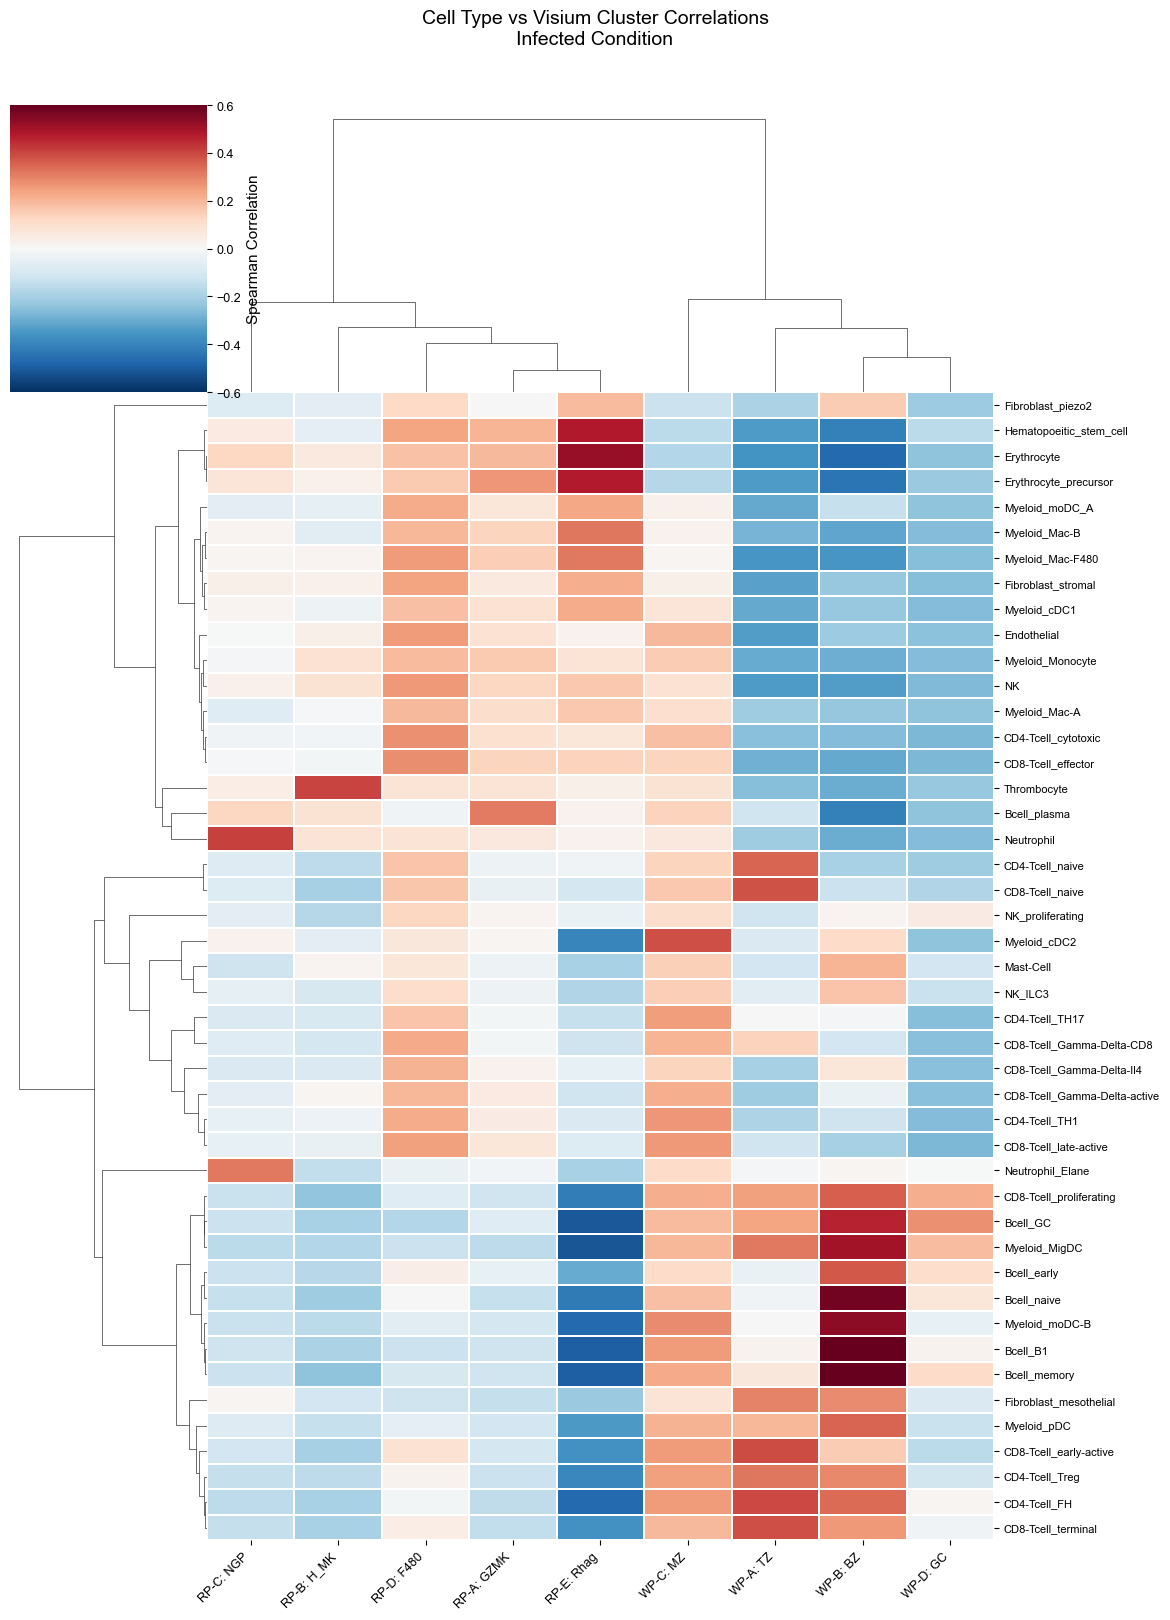

✅ Saved: compact_celltype_vs_cluster_correlations_infected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_infected_correlations.csv and compact_celltype_vs_cluster_correlations_infected_pvalues.csv

PROCESSING UNINFECTED CONDITION
Data shape: (1277, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.538, 0.506]

Creating compact heatmap for Uninfected Condition...


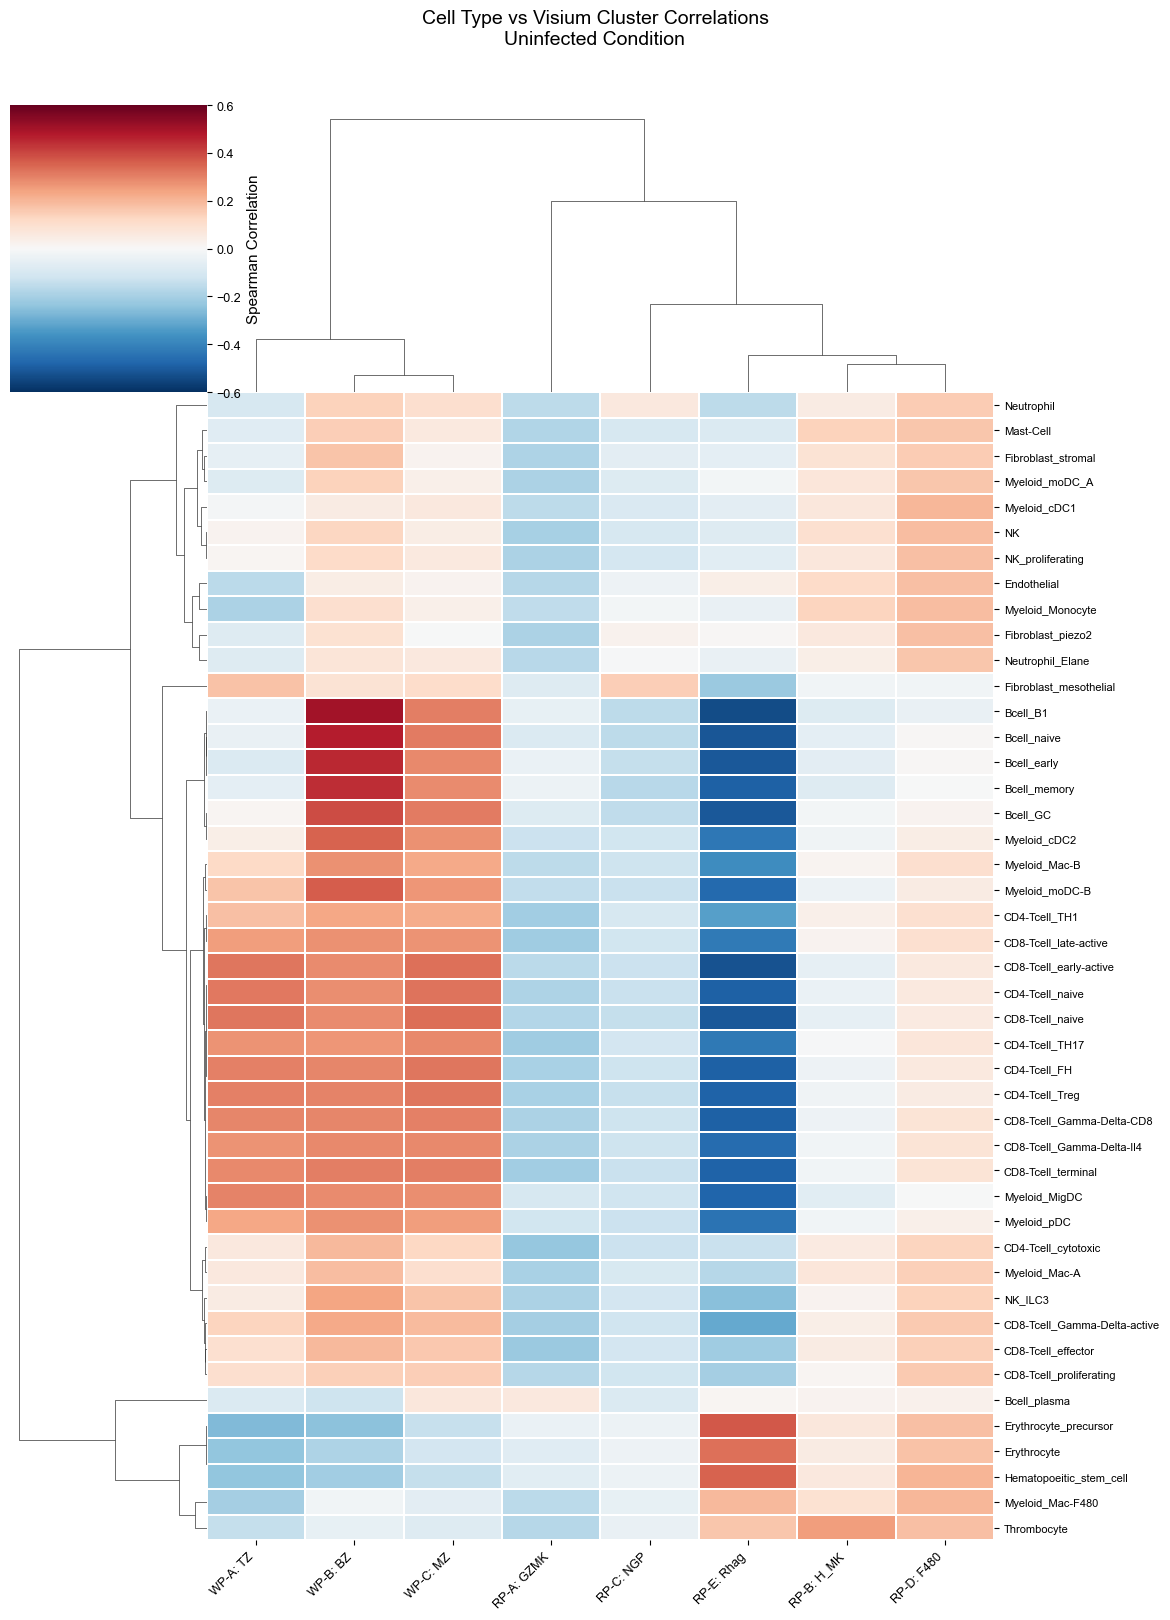

✅ Saved: compact_celltype_vs_cluster_correlations_uninfected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_uninfected_correlations.csv and compact_celltype_vs_cluster_correlations_uninfected_pvalues.csv

INDIVIDUAL SAMPLES

PROCESSING SAMPLE: V1S2
Data shape: (620, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.496, 0.631]

Creating compact heatmap for Sample: V1S2...


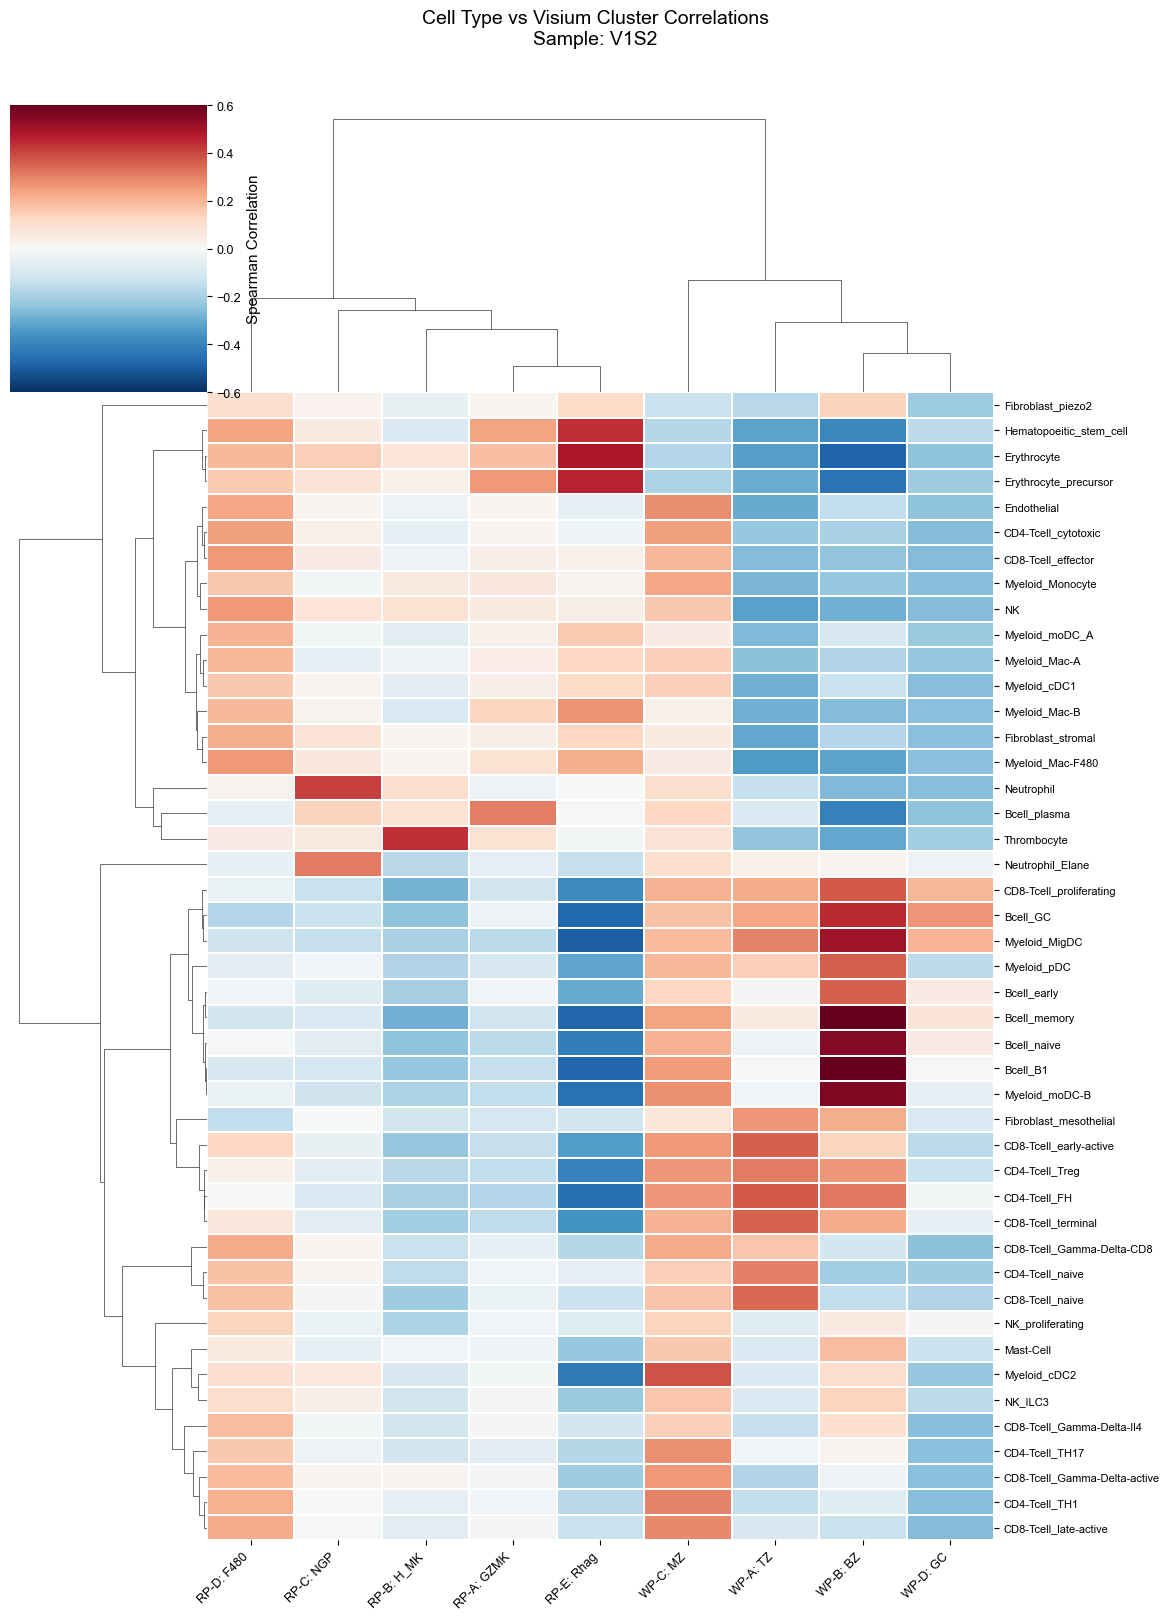

✅ Saved: compact_celltype_vs_cluster_correlations_V1S2.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S2_correlations.csv and compact_celltype_vs_cluster_correlations_V1S2_pvalues.csv

PROCESSING SAMPLE: V1S1
Data shape: (648, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.538, 0.627]

Creating compact heatmap for Sample: V1S1...


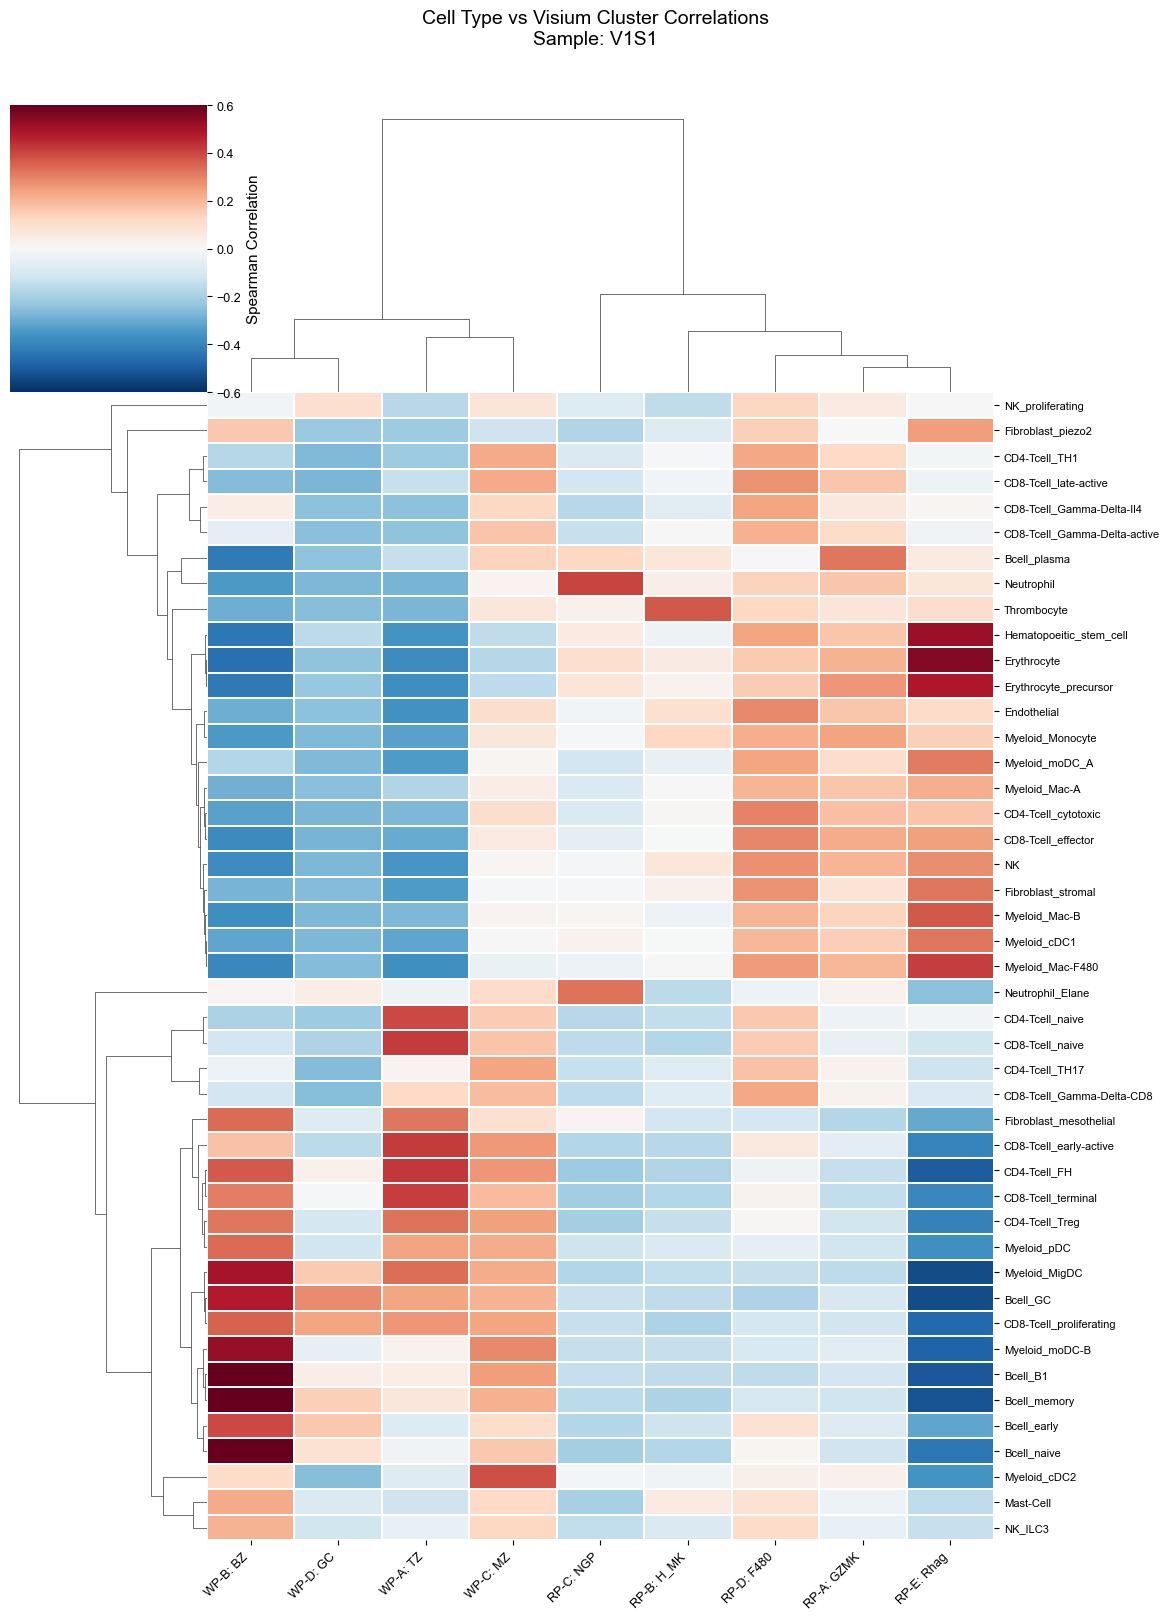

✅ Saved: compact_celltype_vs_cluster_correlations_V1S1.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S1_correlations.csv and compact_celltype_vs_cluster_correlations_V1S1_pvalues.csv

PROCESSING SAMPLE: V1S4
Data shape: (633, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.560, 0.505]

Creating compact heatmap for Sample: V1S4...


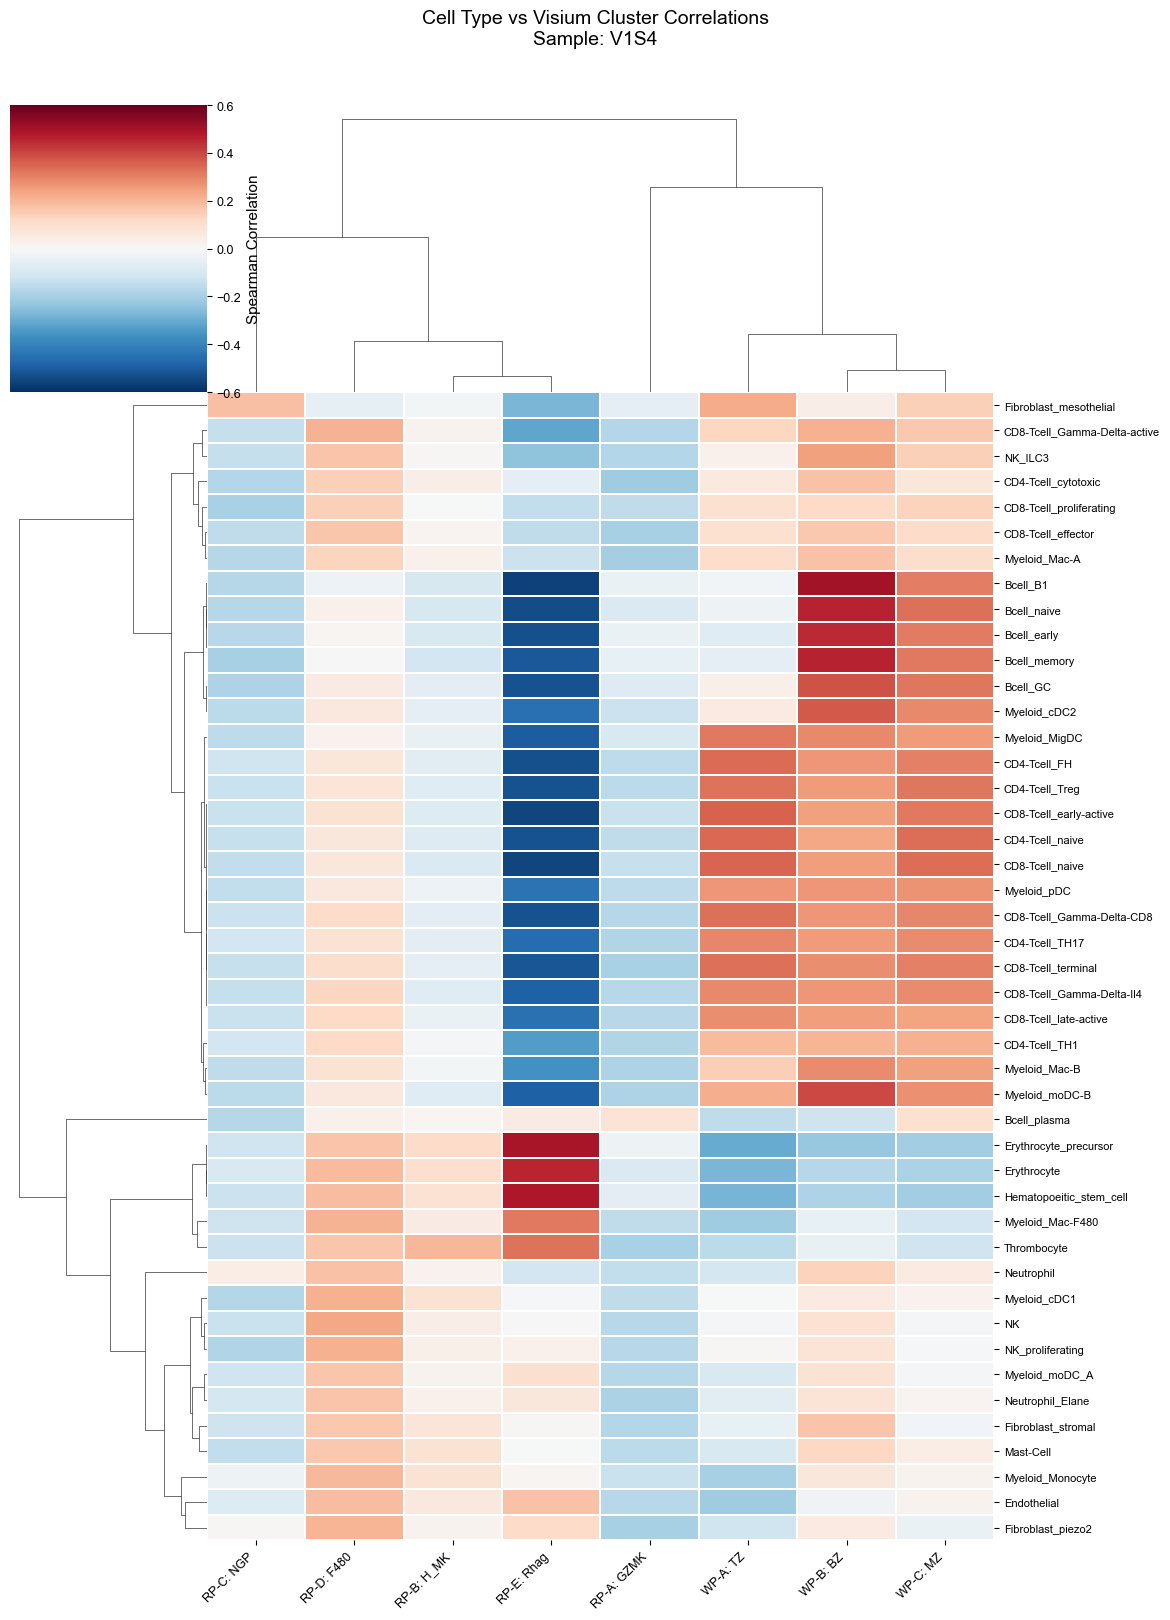

✅ Saved: compact_celltype_vs_cluster_correlations_V1S4.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S4_correlations.csv and compact_celltype_vs_cluster_correlations_V1S4_pvalues.csv

PROCESSING SAMPLE: V1S3
Data shape: (644, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.519, 0.508]

Creating compact heatmap for Sample: V1S3...


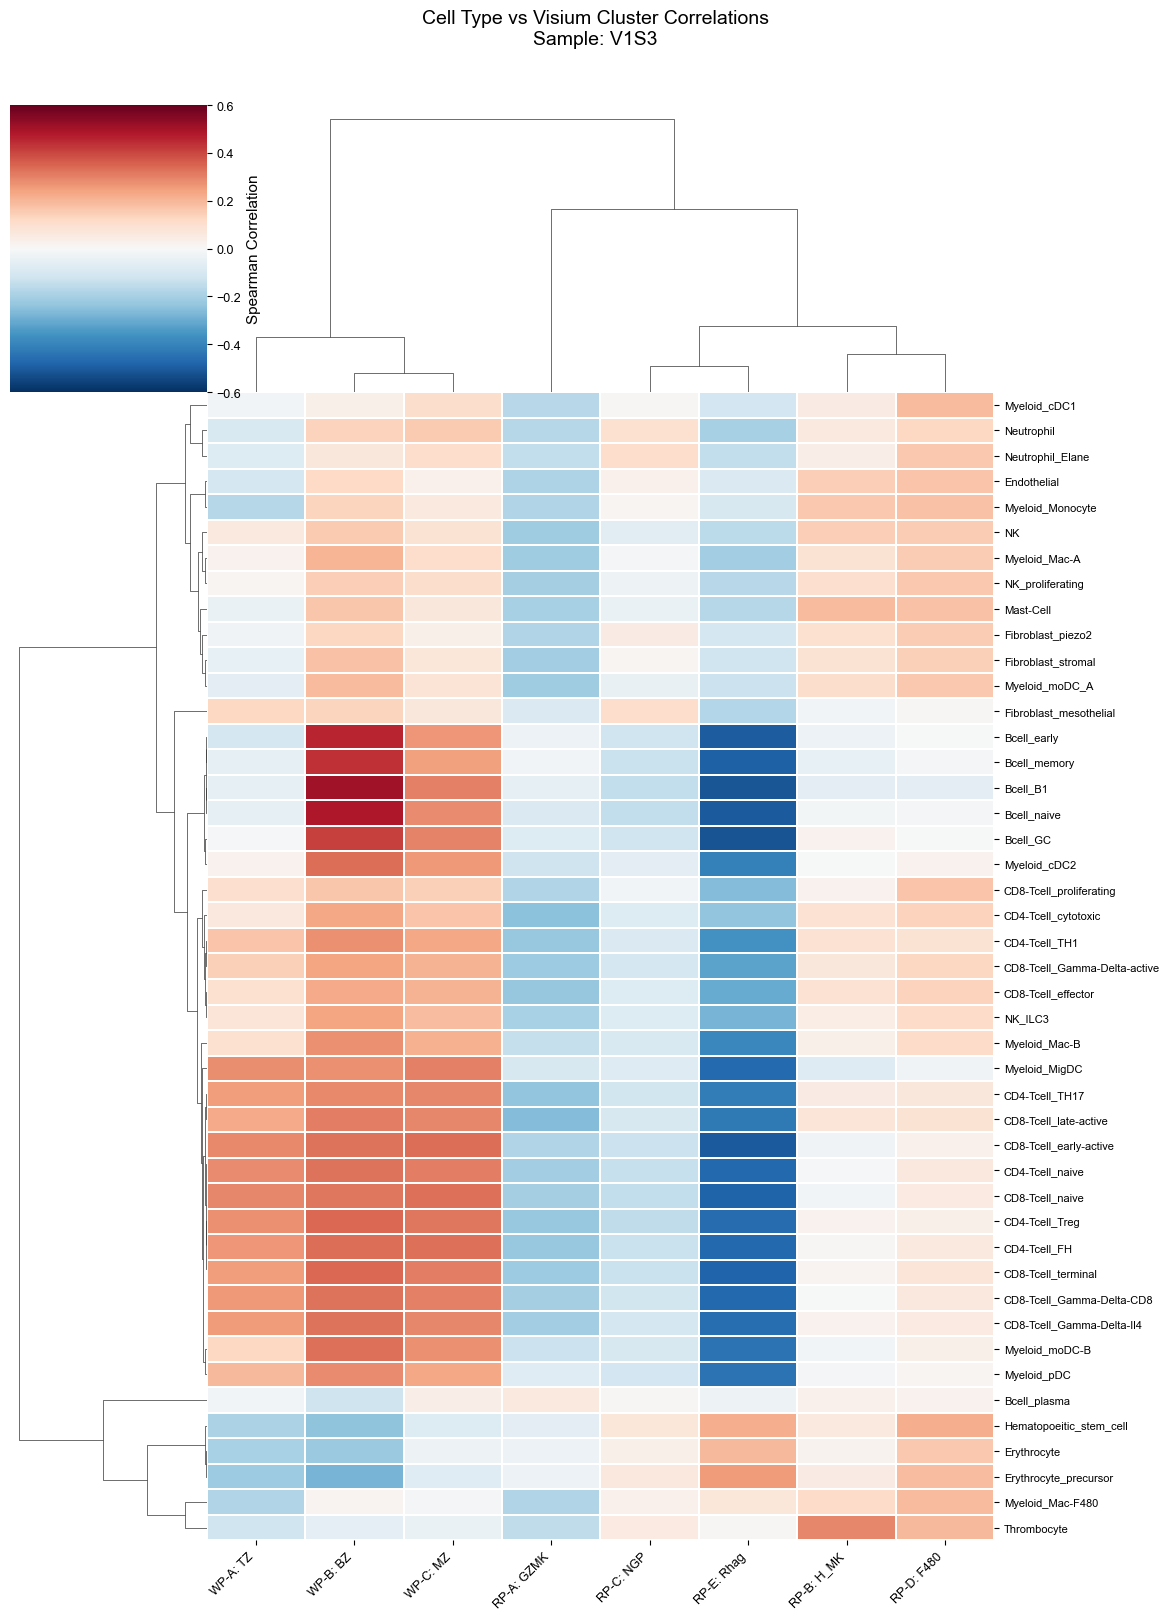

✅ Saved: compact_celltype_vs_cluster_correlations_V1S3.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S3_correlations.csv and compact_celltype_vs_cluster_correlations_V1S3_pvalues.csv

🎉 COMPACT CORRELATION ANALYSIS COMPLETE


In [55]:
#!/usr/bin/env python3
"""
Compact Cell Type vs Visium Cluster Correlation Heatmaps

Create compact correlation heatmaps without significance markers
"""

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr, pearsonr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

def create_compact_celltype_vs_cluster_correlations():
    """
    Create compact correlation heatmaps: Cell types vs Visium clusters
    """
    print("="*80)
    print("COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS")
    print("="*80)
    
    # Load data
    print("Loading data...")
    infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
    uninfected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad'
    
    adata_infected = sc.read_h5ad(infected_path)
    adata_uninfected = sc.read_h5ad(uninfected_path)
    
    def calculate_celltype_cluster_correlations(adata, condition_name):
        """
        Calculate correlations between cell type abundance and cluster membership
        """
        print(f"\n{'='*60}")
        print(f"PROCESSING {condition_name.upper()}")
        print(f"{'='*60}")
        
        # Get abundance data and cluster assignments
        abundance_data = adata.obsm['q05_cell_abundance_w_sf']
        cluster_assignments = adata.obs['paper_clusters'].astype(str)
        
        print(f"Data shape: {abundance_data.shape}")
        print(f"Available clusters: {sorted(cluster_assignments.unique())}")
        
        # Get cell types
        cell_types = abundance_data.columns.tolist()
        clusters = sorted(cluster_assignments.unique())
        
        # Create correlation matrix: cell_types (rows) x clusters (columns)
        correlation_matrix = np.zeros((len(cell_types), len(clusters)))
        pvalue_matrix = np.zeros((len(cell_types), len(clusters)))
        
        print(f"Calculating correlations for {len(cell_types)} cell types vs {len(clusters)} clusters...")
        
        for i, cell_type in enumerate(cell_types):
            cell_abundance = abundance_data[cell_type].values
            
            for j, cluster in enumerate(clusters):
                # Create binary indicator for cluster membership
                cluster_indicator = (cluster_assignments == cluster).astype(int)
                
                # Calculate Spearman correlation
                corr_coef, p_val = spearmanr(cell_abundance, cluster_indicator)
                correlation_matrix[i, j] = corr_coef
                pvalue_matrix[i, j] = p_val
        
        # Convert to DataFrame for easier handling
        corr_df = pd.DataFrame(
            correlation_matrix,
            index=cell_types,
            columns=clusters
        )
        
        pval_df = pd.DataFrame(
            pvalue_matrix,
            index=cell_types,
            columns=clusters
        )
        
        print(f"Correlation matrix shape: {corr_df.shape}")
        print(f"Correlation range: [{np.nanmin(correlation_matrix):.3f}, {np.nanmax(correlation_matrix):.3f}]")
        
        return corr_df, pval_df
    
    def plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename):
        """
        Create compact clustered heatmap - no stars, more condensed
        """
        print(f"\nCreating compact heatmap for {condition_name}...")

        # Remove any rows/columns with all NaN
        corr_df_clean = corr_df.dropna(how='all', axis=0).dropna(how='all', axis=1)

        if corr_df_clean.empty:
            print("❌ No valid correlations found!")
            return

        # Create the clustermap
# Create the clustermap with dummy cbar_pos to ensure it's created
    g = sns.clustermap(
        corr_df_clean,
        cmap='RdBu_r',
        center=0,
        vmin=-0.6,
        vmax=0.6,
        figsize=(12, 16),
        cbar_kws={'label': 'Spearman Correlation'},
        xticklabels=True,
        yticklabels=True,
        linewidths=0.05,
        row_cluster=True,
        col_cluster=True,
        method='average',
        metric='correlation',
        cbar_pos=(0.02, 0.5, 0.02, 0.2)  # placeholder position so seaborn creates it
    )

    # ✅ Now manually move the colorbar to the top-left
    if g.cax:
        g.cax.set_position([0.02, 0.85, 0.015, 0.12])  # [left, bottom, width, height]



        # Customize the plot for compactness - moved title higher to avoid dendrogram overlap
        g.fig.suptitle(f'Cell Type vs Visium Cluster Correlations\n{condition_name}', 
                        fontsize=14, y=0.98)

        # Remove ALL gaps - this is the key fix
        plt.subplots_adjust(top=0.92, hspace=0, wspace=0)

        # Smaller, rotated labels
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=8)


        # Save the plot
        plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', facecolor='white')
        plt.savefig(f'{filename}.pdf', bbox_inches='tight', facecolor='white')
        plt.show()

        print(f"✅ Saved: {filename}.png and .pdf")

        # Save correlation matrix
        corr_df_clean.to_csv(f'{filename}_correlations.csv')
        pval_df.loc[corr_df_clean.index, corr_df_clean.columns].to_csv(f'{filename}_pvalues.csv')
        print(f"✅ Saved: {filename}_correlations.csv and {filename}_pvalues.csv")

        return g
    
    # Process both conditions
    conditions = [
        (adata_infected, "Infected Condition", "compact_celltype_vs_cluster_correlations_infected"),
        (adata_uninfected, "Uninfected Condition", "compact_celltype_vs_cluster_correlations_uninfected")
    ]
    
    for adata, condition_name, filename in conditions:
        # Calculate correlations
        corr_df, pval_df = calculate_celltype_cluster_correlations(adata, condition_name)
        
        # Create compact heatmap
        g = plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename)
    
    # Also create individual sample correlations
    print(f"\n{'='*60}")
    print("INDIVIDUAL SAMPLES")
    print(f"{'='*60}")
    
    # Infected samples
    for sample_name in adata_infected.obs['sample'].unique():
        sample_mask = adata_infected.obs['sample'] == sample_name
        sample_adata = adata_infected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename)
    
    # Uninfected samples  
    for sample_name in adata_uninfected.obs['sample'].unique():
        sample_mask = adata_uninfected.obs['sample'] == sample_name
        sample_adata = adata_uninfected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename)
    
    print(f"\n{'='*80}")
    print("🎉 COMPACT CORRELATION ANALYSIS COMPLETE")
    print(f"{'='*80}")

# Run the analysis
create_compact_celltype_vs_cluster_correlations()

COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS
Loading data...

PROCESSING INFECTED CONDITION
Data shape: (1268, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.512, 0.629]

Creating compact heatmap for Infected Condition...


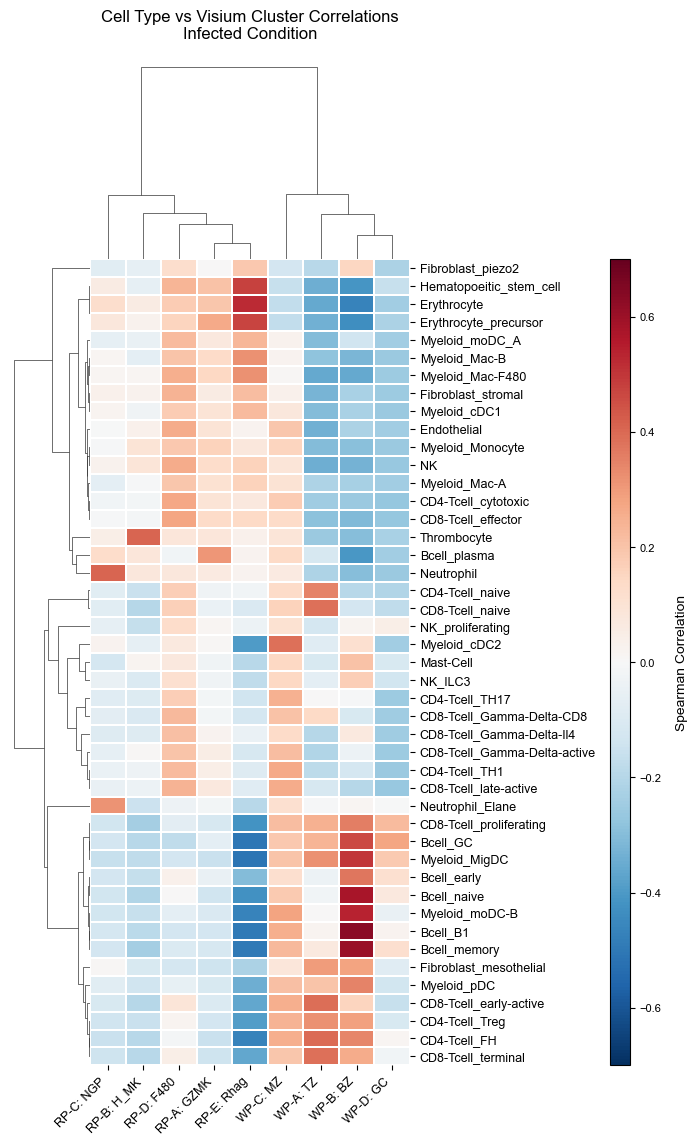

✅ Saved: compact_celltype_vs_cluster_correlations_infected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_infected_correlations.csv and compact_celltype_vs_cluster_correlations_infected_pvalues.csv

PROCESSING UNINFECTED CONDITION
Data shape: (1277, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.538, 0.506]

Creating compact heatmap for Uninfected Condition...


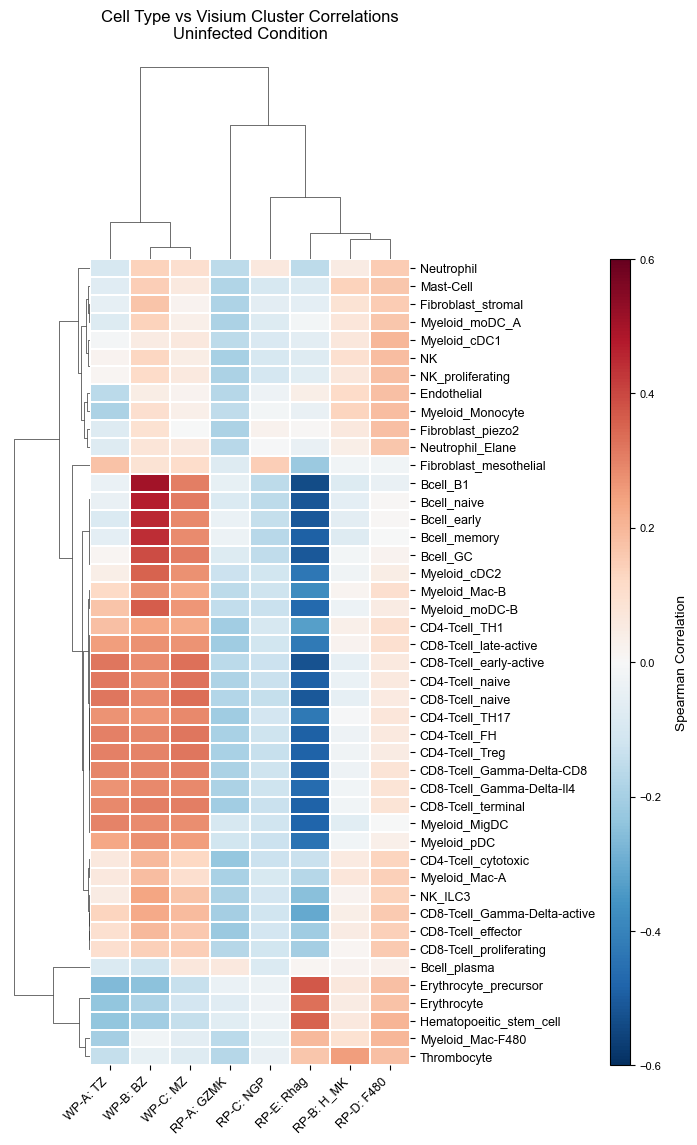

✅ Saved: compact_celltype_vs_cluster_correlations_uninfected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_uninfected_correlations.csv and compact_celltype_vs_cluster_correlations_uninfected_pvalues.csv

INDIVIDUAL SAMPLES

PROCESSING SAMPLE: V1S2
Data shape: (620, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.496, 0.631]

Creating compact heatmap for Sample: V1S2...


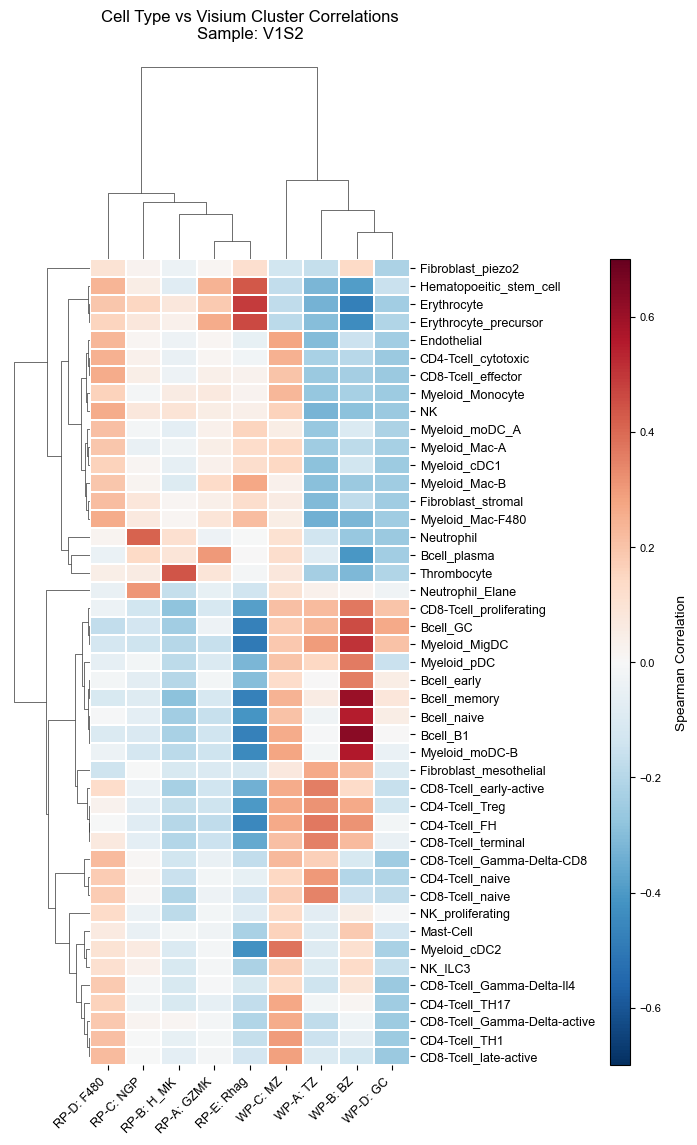

✅ Saved: compact_celltype_vs_cluster_correlations_V1S2.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S2_correlations.csv and compact_celltype_vs_cluster_correlations_V1S2_pvalues.csv

PROCESSING SAMPLE: V1S1
Data shape: (648, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.538, 0.627]

Creating compact heatmap for Sample: V1S1...


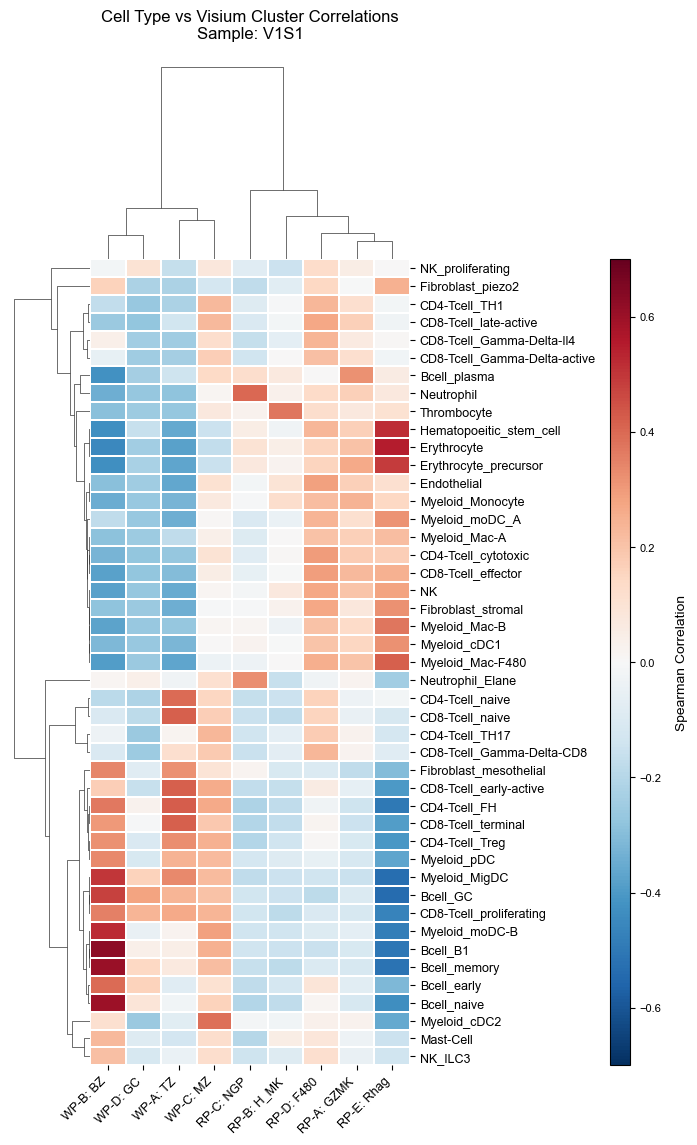

✅ Saved: compact_celltype_vs_cluster_correlations_V1S1.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S1_correlations.csv and compact_celltype_vs_cluster_correlations_V1S1_pvalues.csv

PROCESSING SAMPLE: V1S4
Data shape: (633, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.560, 0.505]

Creating compact heatmap for Sample: V1S4...


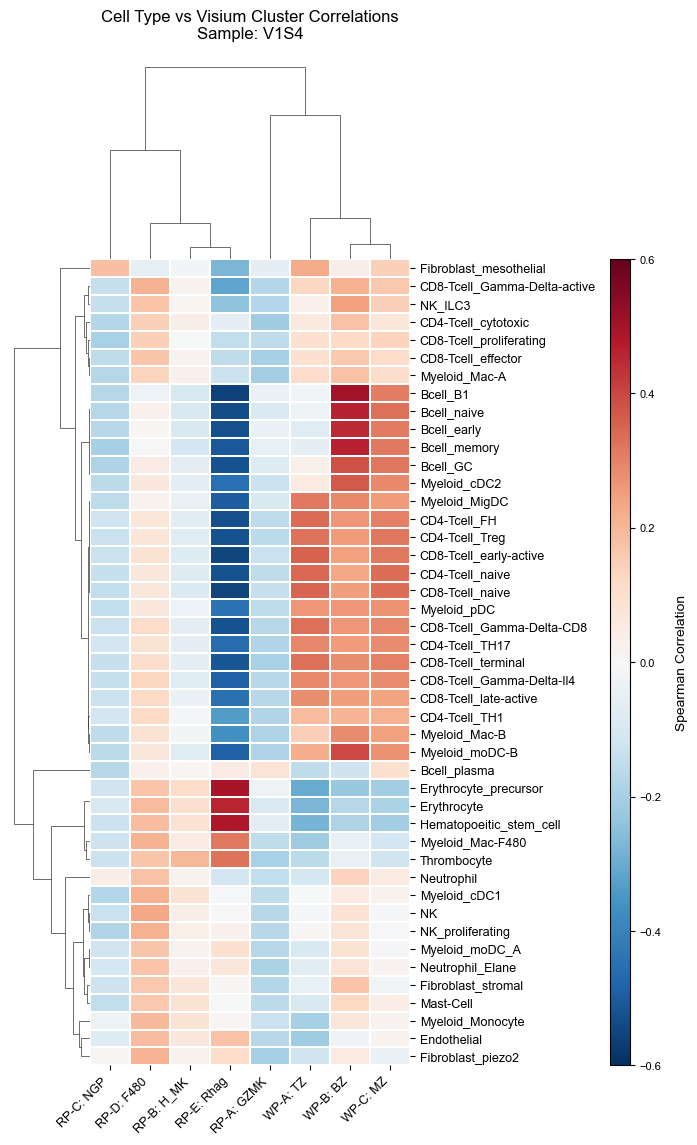

✅ Saved: compact_celltype_vs_cluster_correlations_V1S4.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S4_correlations.csv and compact_celltype_vs_cluster_correlations_V1S4_pvalues.csv

PROCESSING SAMPLE: V1S3
Data shape: (644, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.519, 0.508]

Creating compact heatmap for Sample: V1S3...


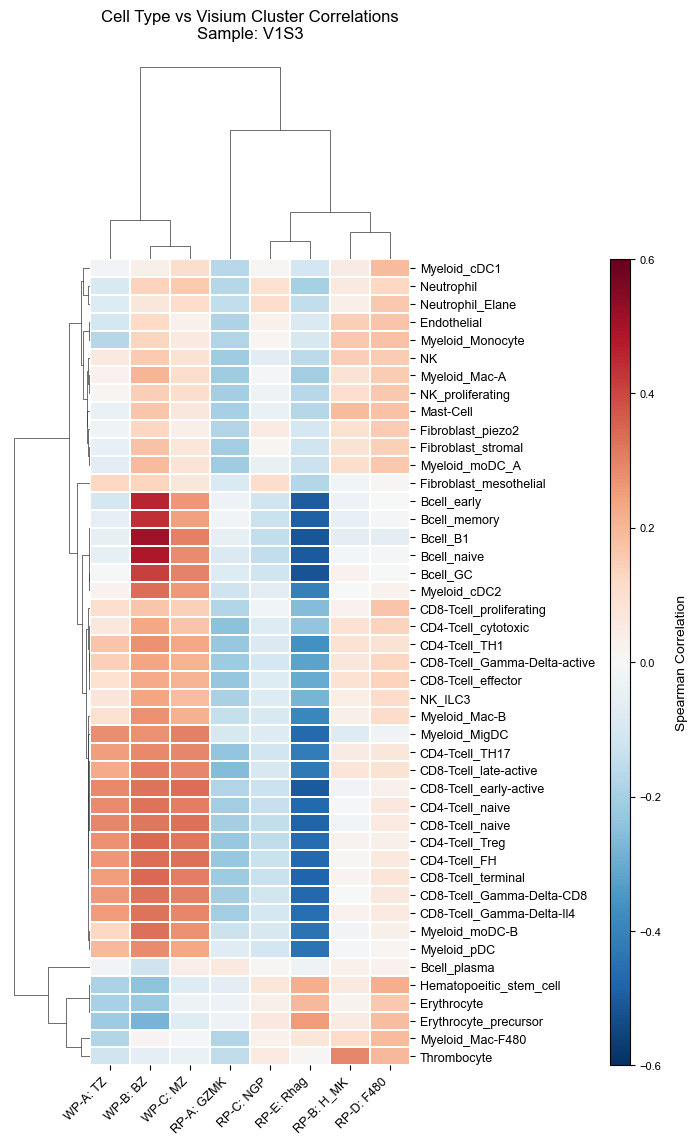

✅ Saved: compact_celltype_vs_cluster_correlations_V1S3.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S3_correlations.csv and compact_celltype_vs_cluster_correlations_V1S3_pvalues.csv

🎉 COMPACT CORRELATION ANALYSIS COMPLETE


In [73]:
#!/usr/bin/env python3
"""
Compact Cell Type vs Visium Cluster Correlation Heatmaps

Create compact correlation heatmaps without significance markers
"""

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

def create_compact_celltype_vs_cluster_correlations():
    """
    Create compact correlation heatmaps: Cell types vs Visium clusters
    """
    print("="*80)
    print("COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS")
    print("="*80)
    
    # Load data
    print("Loading data...")
    infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
    uninfected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad'
    
    adata_infected = sc.read_h5ad(infected_path)
    adata_uninfected = sc.read_h5ad(uninfected_path)
    
    def calculate_celltype_cluster_correlations(adata, condition_name):
        """
        Calculate correlations between cell type abundance and cluster membership
        """
        print(f"\n{'='*60}")
        print(f"PROCESSING {condition_name.upper()}")
        print(f"{'='*60}")
        
        # Get abundance data and cluster assignments
        abundance_data = adata.obsm['q05_cell_abundance_w_sf']
        cluster_assignments = adata.obs['paper_clusters'].astype(str)
        
        print(f"Data shape: {abundance_data.shape}")
        print(f"Available clusters: {sorted(cluster_assignments.unique())}")
        
        # Get cell types
        cell_types = abundance_data.columns.tolist()
        clusters = sorted(cluster_assignments.unique())
        
        # Create correlation matrix: cell_types (rows) x clusters (columns)
        correlation_matrix = np.zeros((len(cell_types), len(clusters)))
        pvalue_matrix = np.zeros((len(cell_types), len(clusters)))
        
        print(f"Calculating correlations for {len(cell_types)} cell types vs {len(clusters)} clusters...")
        
        for i, cell_type in enumerate(cell_types):
            cell_abundance = abundance_data[cell_type].values
            
            for j, cluster in enumerate(clusters):
                # Create binary indicator for cluster membership
                cluster_indicator = (cluster_assignments == cluster).astype(int)
                
                # Calculate Spearman correlation
                corr_coef, p_val = spearmanr(cell_abundance, cluster_indicator)
                correlation_matrix[i, j] = corr_coef
                pvalue_matrix[i, j] = p_val
        
        # Convert to DataFrame for easier handling
        corr_df = pd.DataFrame(
            correlation_matrix,
            index=cell_types,
            columns=clusters
        )
        
        pval_df = pd.DataFrame(
            pvalue_matrix,
            index=cell_types,
            columns=clusters
        )
        
        print(f"Correlation matrix shape: {corr_df.shape}")
        print(f"Correlation range: [{np.nanmin(correlation_matrix):.3f}, {np.nanmax(correlation_matrix):.3f}]")
        
        return corr_df, pval_df
    
    def plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename):
        """
        Create publication-quality compact clustered heatmap with colorbar at far right
        """
        print(f"\nCreating compact heatmap for {condition_name}...")

        # Remove any rows/columns with all NaN
        corr_df_clean = corr_df.dropna(how='all', axis=0).dropna(how='all', axis=1)

        if corr_df_clean.empty:
            print("❌ No valid correlations found!")
            return

        # Calculate dynamic vmin/vmax symmetric around 0
        max_abs = np.ceil(np.nanmax(np.abs(corr_df_clean.values)) * 10) / 10
        vmin_dyn = -max_abs
        vmax_dyn = max_abs

        # Create the clustermap without automatic colorbar
        g = sns.clustermap(
            corr_df_clean,
            cmap='RdBu_r',
            center=0,
            vmin=vmin_dyn,
            vmax=vmax_dyn,
            figsize=(10, 12),  # Slightly smaller for better proportions
            xticklabels=True,
            yticklabels=True,
            linewidths=0.1,
            row_cluster=True,
            col_cluster=True,
            method='average',
            metric='correlation',
            cbar_pos=None,  # No automatic colorbar
            annot=None
        )

        # COORDINATED LAYOUT: Set margins with extra space on right for colorbar
        plt.subplots_adjust(top=0.92, bottom=0.08, left=0.25, right=0.65, hspace=0, wspace=0)
        
        # Get the actual heatmap position after layout adjustment
        heatmap_pos = g.ax_heatmap.get_position()
        
        # Position colorbar at the far right edge of the figure
        cbar_left = 0.85  # Far right position
        cbar_bottom = heatmap_pos.y0      # Aligned with bottom of heatmap
        cbar_width = 0.02
        cbar_height = heatmap_pos.height  # Same height as heatmap
        
        cax = g.fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
        cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax, orientation='vertical')
        cbar.set_label('Spearman Correlation', fontsize=10, labelpad=10)
        cbar.ax.tick_params(labelsize=8)

        # Title positioned relative to the heatmap center
        heatmap_center_x = heatmap_pos.x0 + heatmap_pos.width / 2
        g.fig.suptitle(f'Cell Type vs Visium Cluster Correlations\n{condition_name}', 
                       fontsize=12, x=heatmap_center_x, y=0.96, ha='center')

        # Clean, readable labels
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

        # Save with publication quality
        plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.savefig(f'{filename}.pdf', bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.show()

        print(f"✅ Saved: {filename}.png and .pdf")

        # Save data
        corr_df_clean.to_csv(f'{filename}_correlations.csv')
        pval_df.loc[corr_df_clean.index, corr_df_clean.columns].to_csv(f'{filename}_pvalues.csv')
        print(f"✅ Saved: {filename}_correlations.csv and {filename}_pvalues.csv")

        return g
    
    # Process both conditions
    conditions = [
        (adata_infected, "Infected Condition", "compact_celltype_vs_cluster_correlations_infected"),
        (adata_uninfected, "Uninfected Condition", "compact_celltype_vs_cluster_correlations_uninfected")
    ]
    
    for adata, condition_name, filename in conditions:
        # Calculate correlations
        corr_df, pval_df = calculate_celltype_cluster_correlations(adata, condition_name)
        
        # Create compact heatmap
        g = plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename)
    
    # Also create individual sample correlations
    print(f"\n{'='*60}")
    print("INDIVIDUAL SAMPLES")
    print(f"{'='*60}")
    
    # Infected samples
    for sample_name in adata_infected.obs['sample'].unique():
        sample_mask = adata_infected.obs['sample'] == sample_name
        sample_adata = adata_infected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename)
    
    # Uninfected samples  
    for sample_name in adata_uninfected.obs['sample'].unique():
        sample_mask = adata_uninfected.obs['sample'] == sample_name
        sample_adata = adata_uninfected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename)
    
    print(f"\n{'='*80}")
    print("🎉 COMPACT CORRELATION ANALYSIS COMPLETE")
    print(f"{'='*80}")

# Run the analysis
create_compact_celltype_vs_cluster_correlations()

COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS
Loading data...

PROCESSING INFECTED CONDITION
Data shape: (1268, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.512, 0.629]

Creating compact heatmap for Infected Condition...


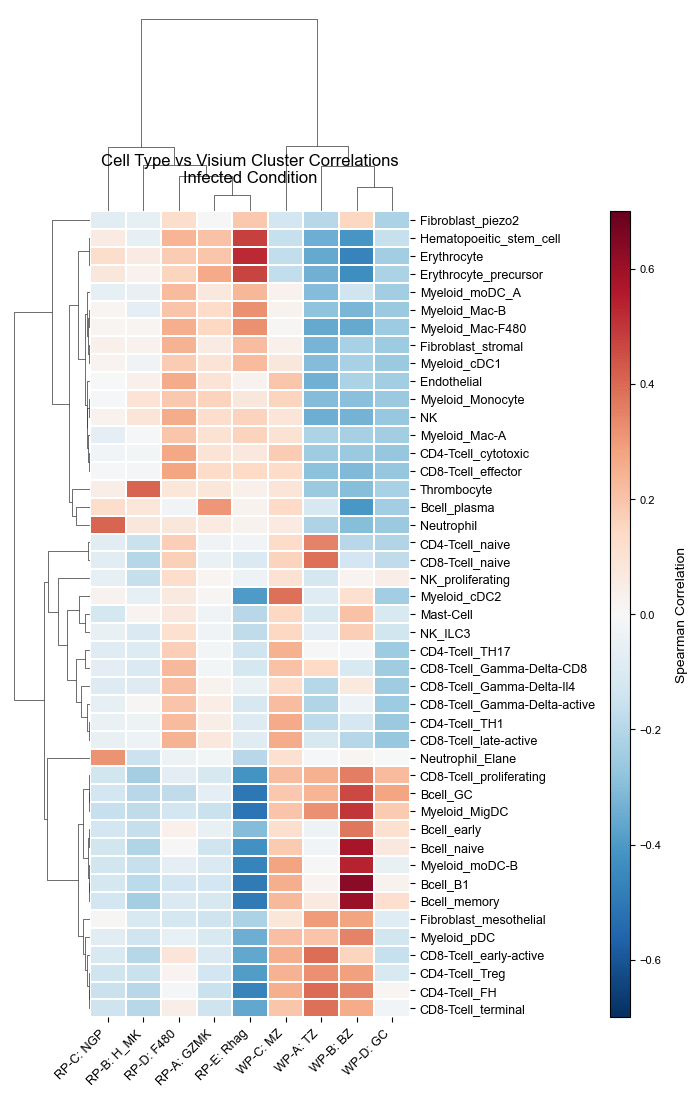

✅ Saved: compact_celltype_vs_cluster_correlations_infected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_infected_correlations.csv and compact_celltype_vs_cluster_correlations_infected_pvalues.csv

PROCESSING UNINFECTED CONDITION
Data shape: (1277, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.538, 0.506]

Creating compact heatmap for Uninfected Condition...


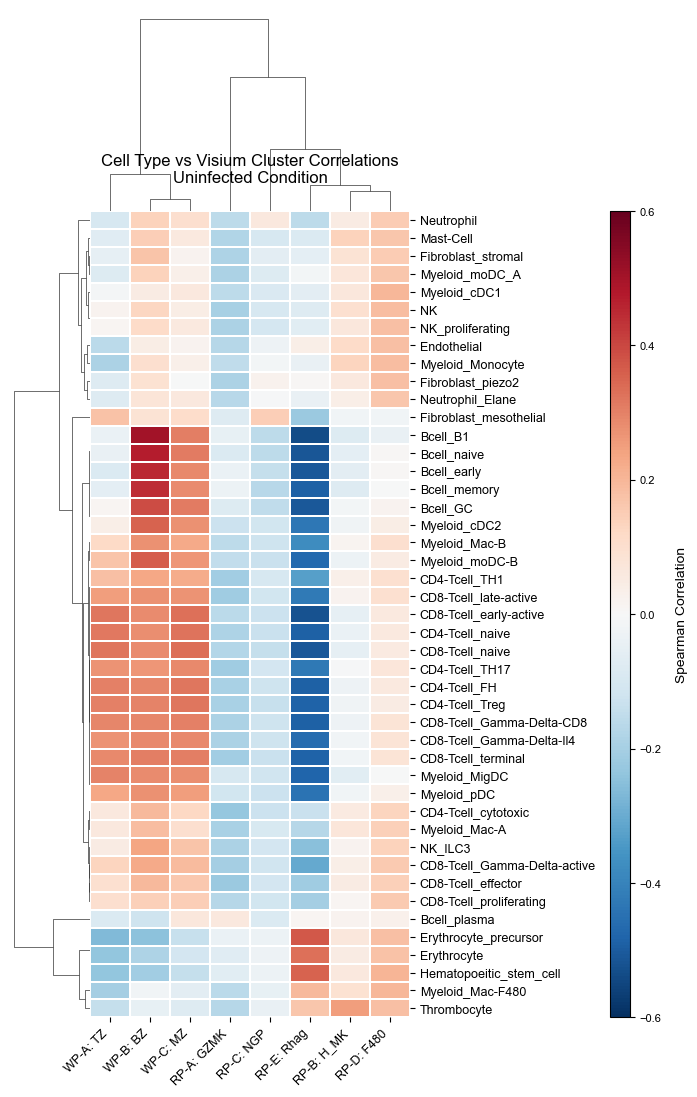

✅ Saved: compact_celltype_vs_cluster_correlations_uninfected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_uninfected_correlations.csv and compact_celltype_vs_cluster_correlations_uninfected_pvalues.csv

INDIVIDUAL SAMPLES (Using consistent ordering)

PROCESSING SAMPLE: V1S2
Data shape: (620, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.496, 0.631]

Creating compact heatmap for Sample: V1S2...


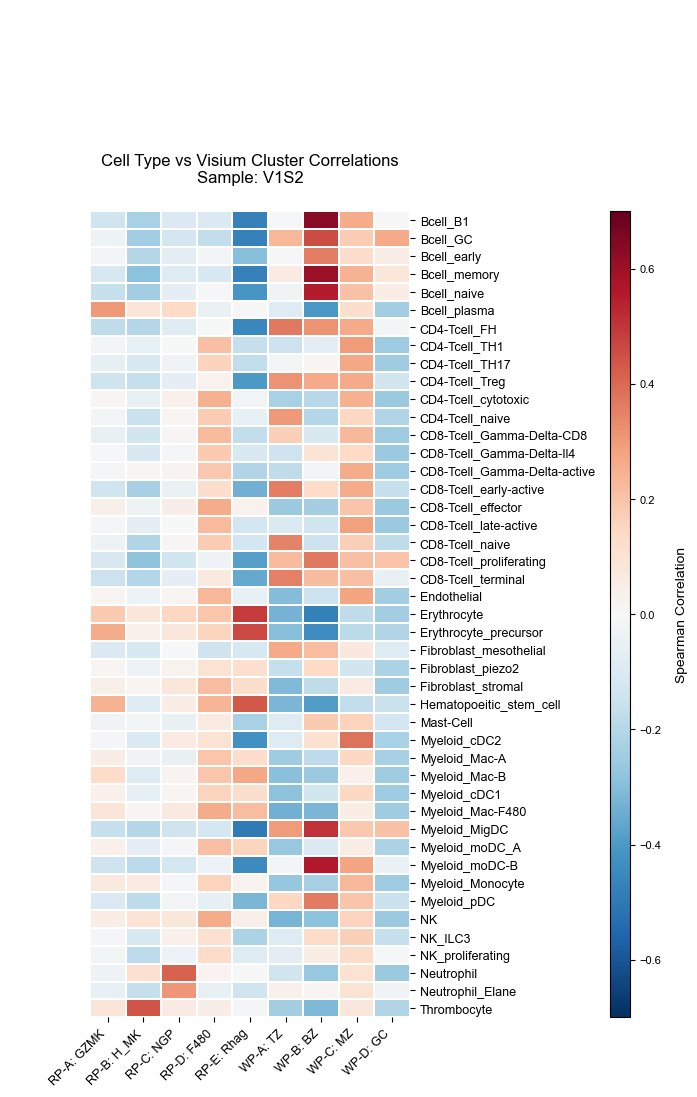

✅ Saved: compact_celltype_vs_cluster_correlations_V1S2.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S2_correlations.csv and compact_celltype_vs_cluster_correlations_V1S2_pvalues.csv

PROCESSING SAMPLE: V1S1
Data shape: (648, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.538, 0.627]

Creating compact heatmap for Sample: V1S1...


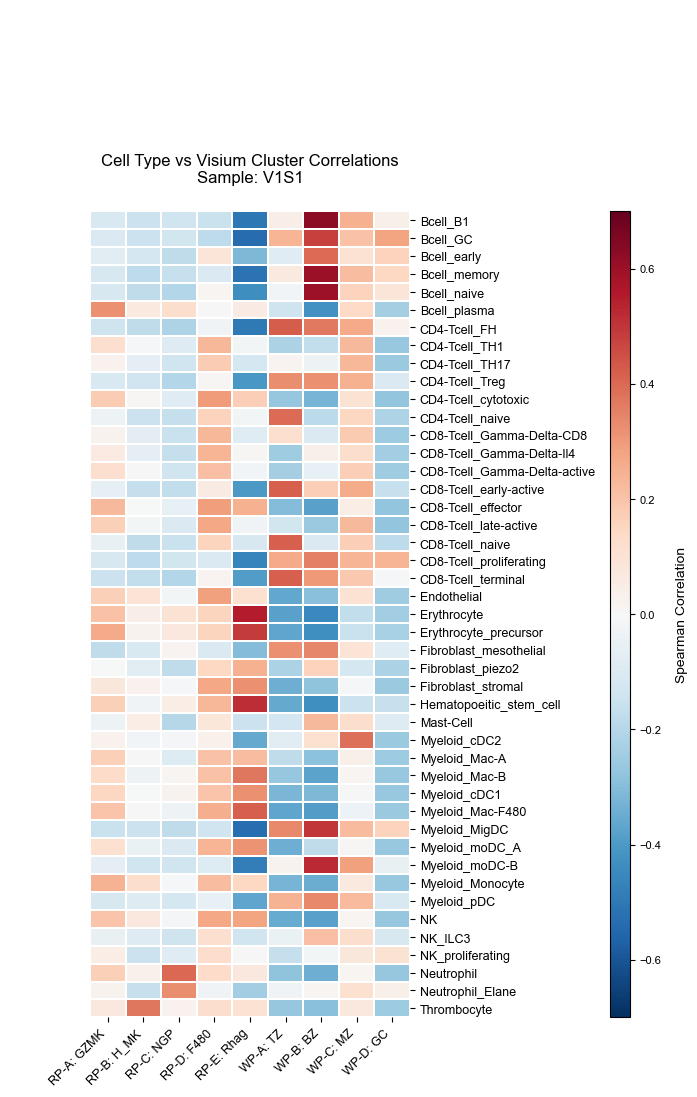

✅ Saved: compact_celltype_vs_cluster_correlations_V1S1.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S1_correlations.csv and compact_celltype_vs_cluster_correlations_V1S1_pvalues.csv

🎉 COMPACT CORRELATION ANALYSIS COMPLETE


In [87]:
#!/usr/bin/env python3
"""
Compact Cell Type vs Visium Cluster Correlation Heatmaps

Create compact correlation heatmaps without significance markers
"""

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

def create_compact_celltype_vs_cluster_correlations():
    """
    Create compact correlation heatmaps: Cell types vs Visium clusters
    """
    print("="*80)
    print("COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS")
    print("="*80)
    
    # Load data
    print("Loading data...")
    infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
    uninfected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad'
    
    adata_infected = sc.read_h5ad(infected_path)
    adata_uninfected = sc.read_h5ad(uninfected_path)
    
    def calculate_celltype_cluster_correlations(adata, condition_name):
        """
        Calculate correlations between cell type abundance and cluster membership
        """
        print(f"\n{'='*60}")
        print(f"PROCESSING {condition_name.upper()}")
        print(f"{'='*60}")
        
        # Get abundance data and cluster assignments
        abundance_data = adata.obsm['q05_cell_abundance_w_sf']
        cluster_assignments = adata.obs['paper_clusters'].astype(str)
        
        print(f"Data shape: {abundance_data.shape}")
        print(f"Available clusters: {sorted(cluster_assignments.unique())}")
        
        # Get cell types
        cell_types = abundance_data.columns.tolist()
        clusters = sorted(cluster_assignments.unique())
        
        # Create correlation matrix: cell_types (rows) x clusters (columns)
        correlation_matrix = np.zeros((len(cell_types), len(clusters)))
        pvalue_matrix = np.zeros((len(cell_types), len(clusters)))
        
        print(f"Calculating correlations for {len(cell_types)} cell types vs {len(clusters)} clusters...")
        
        for i, cell_type in enumerate(cell_types):
            cell_abundance = abundance_data[cell_type].values
            
            for j, cluster in enumerate(clusters):
                # Create binary indicator for cluster membership
                cluster_indicator = (cluster_assignments == cluster).astype(int)
                
                # Calculate Spearman correlation
                corr_coef, p_val = spearmanr(cell_abundance, cluster_indicator)
                correlation_matrix[i, j] = corr_coef
                pvalue_matrix[i, j] = p_val
        
        # Convert to DataFrame for easier handling
        corr_df = pd.DataFrame(
            correlation_matrix,
            index=cell_types,
            columns=clusters
        )
        
        pval_df = pd.DataFrame(
            pvalue_matrix,
            index=cell_types,
            columns=clusters
        )
        
        print(f"Correlation matrix shape: {corr_df.shape}")
        print(f"Correlation range: [{np.nanmin(correlation_matrix):.3f}, {np.nanmax(correlation_matrix):.3f}]")
        
        return corr_df, pval_df
    
    def plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename, use_clustering=True, row_order=None, col_order=None):
        """
        Create publication-quality compact clustered heatmap with colorbar at far right
        If use_clustering=False, uses provided row_order and col_order instead of dendrograms
        """
        print(f"\nCreating compact heatmap for {condition_name}...")

        # Remove any rows/columns with all NaN
        corr_df_clean = corr_df.dropna(how='all', axis=0).dropna(how='all', axis=1)

        if corr_df_clean.empty:
            print("❌ No valid correlations found!")
            return

        # If not using clustering and orders are provided, reorder the data
        if not use_clustering and row_order is not None and col_order is not None:
            # Reorder to match the provided ordering
            available_rows = [r for r in row_order if r in corr_df_clean.index]
            available_cols = [c for c in col_order if c in corr_df_clean.columns]
            corr_df_clean = corr_df_clean.loc[available_rows, available_cols]

        # Calculate dynamic vmin/vmax symmetric around 0
        max_abs = np.ceil(np.nanmax(np.abs(corr_df_clean.values)) * 10) / 10
        vmin_dyn = -max_abs
        vmax_dyn = max_abs

        # Create the clustermap with or without clustering
        g = sns.clustermap(
            corr_df_clean,
            cmap='RdBu_r',
            center=0,
            vmin=vmin_dyn,
            vmax=vmax_dyn,
            figsize=(10, 12),  # Slightly smaller for better proportions
            xticklabels=True,
            yticklabels=True,
            linewidths=0.1,
            row_cluster=use_clustering,  # Turn off clustering for individual samples
            col_cluster=use_clustering,  # Turn off clustering for individual samples
            method='average',
            metric='correlation',
            cbar_pos=None,  # No automatic colorbar
            annot=None
        )

        # COORDINATED LAYOUT: Set margins with extra space on right for colorbar
        plt.subplots_adjust(top=0.92, bottom=0.08, left=0.25, right=0.65, hspace=0, wspace=0)
        
        # Get the actual heatmap position after layout adjustment
        heatmap_pos = g.ax_heatmap.get_position()
        
        # Position colorbar at the far right edge of the figure
        cbar_left = 0.85  # Far right position
        cbar_bottom = heatmap_pos.y0      # Aligned with bottom of heatmap
        cbar_width = 0.02
        cbar_height = heatmap_pos.height  # Same height as heatmap
        
        cax = g.fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
        cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax, orientation='vertical')
        cbar.set_label('Spearman Correlation', fontsize=10, labelpad=10)
        cbar.ax.tick_params(labelsize=8)

        # Title positioned relative to the heatmap center
        heatmap_center_x = heatmap_pos.x0 + heatmap_pos.width / 2
        g.fig.suptitle(f'Cell Type vs Visium Cluster Correlations\n{condition_name}', 
                       fontsize=12, x=heatmap_center_x, y=0.8, ha='center')

        # Clean, readable labels
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

        # Save with publication quality
        plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.savefig(f'{filename}.pdf', bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.show()

        print(f"✅ Saved: {filename}.png and .pdf")

        # Save data
        corr_df_clean.to_csv(f'{filename}_correlations.csv')
        pval_df.loc[corr_df_clean.index, corr_df_clean.columns].to_csv(f'{filename}_pvalues.csv')
        print(f"✅ Saved: {filename}_correlations.csv and {filename}_pvalues.csv")

        return g, corr_df_clean.index.tolist(), corr_df_clean.columns.tolist()  # Return the ordering
    
    # Process both conditions first to get the ordering
    conditions = [
        (adata_infected, "Infected Condition", "compact_celltype_vs_cluster_correlations_infected"),
        (adata_uninfected, "Uninfected Condition", "compact_celltype_vs_cluster_correlations_uninfected")
    ]
    
    # Store the ordering from the first clustered heatmap
    reference_row_order = None
    reference_col_order = None
    
    for adata, condition_name, filename in conditions:
        # Calculate correlations
        corr_df, pval_df = calculate_celltype_cluster_correlations(adata, condition_name)
        
        # Create compact heatmap with clustering
        g, row_order, col_order = plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename, use_clustering=True)
        
        # Store the ordering from the infected condition for individual samples
        if condition_name == "Infected Condition":
            reference_row_order = row_order
            reference_col_order = col_order
    
    # Also create individual sample correlations using the reference ordering
    print(f"\n{'='*60}")
    print("INDIVIDUAL SAMPLES (Using consistent ordering)")
    print(f"{'='*60}")
    
    # Infected samples - use the reference ordering, no clustering
    for sample_name in adata_infected.obs['sample'].unique():
        sample_mask = adata_infected.obs['sample'] == sample_name
        sample_adata = adata_infected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g, _, _ = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename, 
                                                 use_clustering=False, row_order=reference_row_order, col_order=reference_col_order)
    
    print(f"\n{'='*80}")
    print("🎉 COMPACT CORRELATION ANALYSIS COMPLETE")
    print(f"{'='*80}")

# Run the analysis
create_compact_celltype_vs_cluster_correlations()

COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS
Loading data...

PROCESSING INFECTED CONDITION
Data shape: (1268, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.512, 0.629]

Creating compact heatmap for Infected Condition...


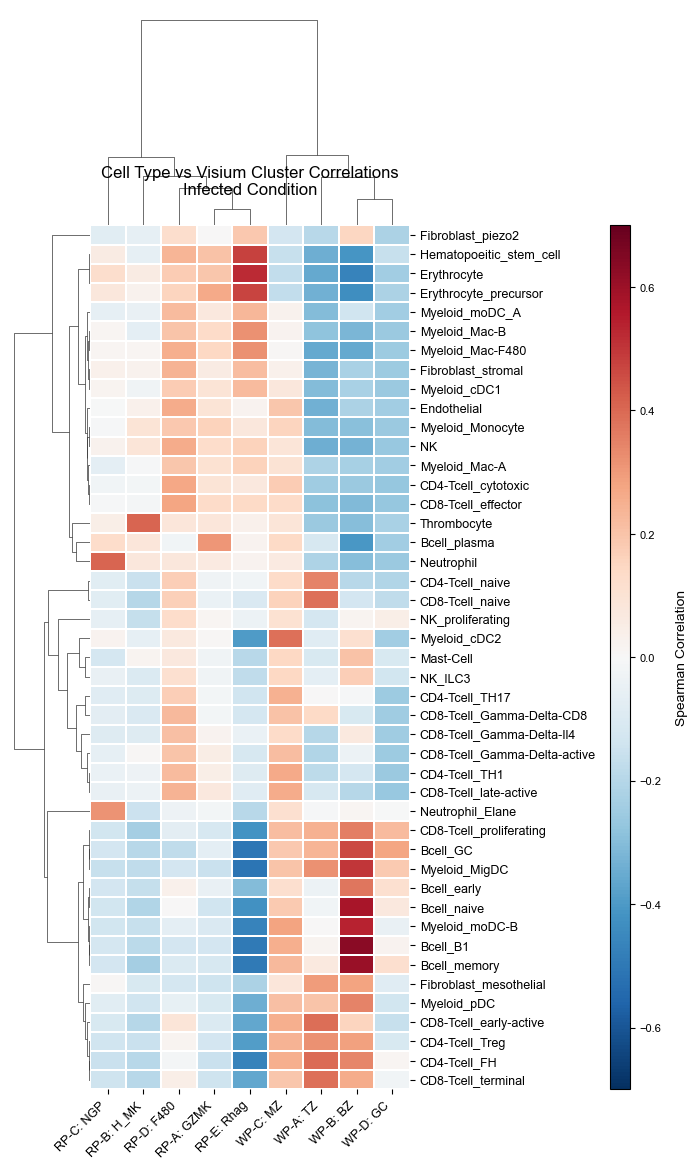

✅ Saved: compact_celltype_vs_cluster_correlations_infected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_infected_correlations.csv and compact_celltype_vs_cluster_correlations_infected_pvalues.csv

PROCESSING UNINFECTED CONDITION
Data shape: (1277, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.538, 0.506]

Creating compact heatmap for Uninfected Condition...


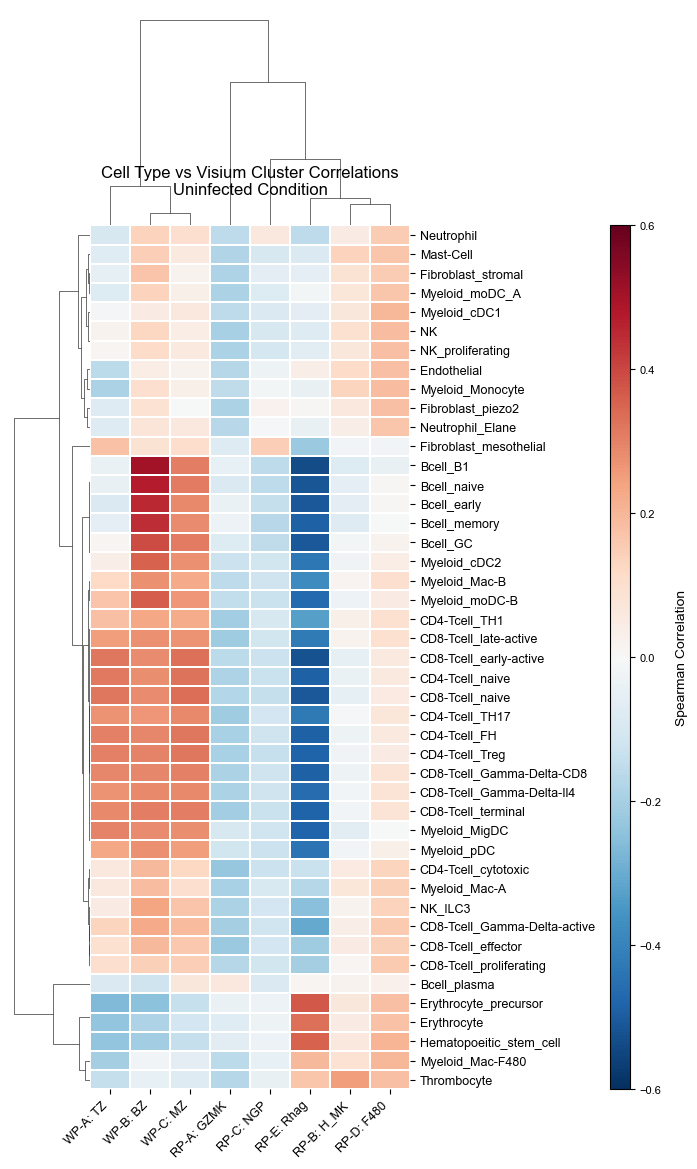

✅ Saved: compact_celltype_vs_cluster_correlations_uninfected.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_uninfected_correlations.csv and compact_celltype_vs_cluster_correlations_uninfected_pvalues.csv

INDIVIDUAL SAMPLES (Using consistent ordering)

PROCESSING SAMPLE: V1S2
Data shape: (620, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.496, 0.631]

Creating compact heatmap for Sample: V1S2...


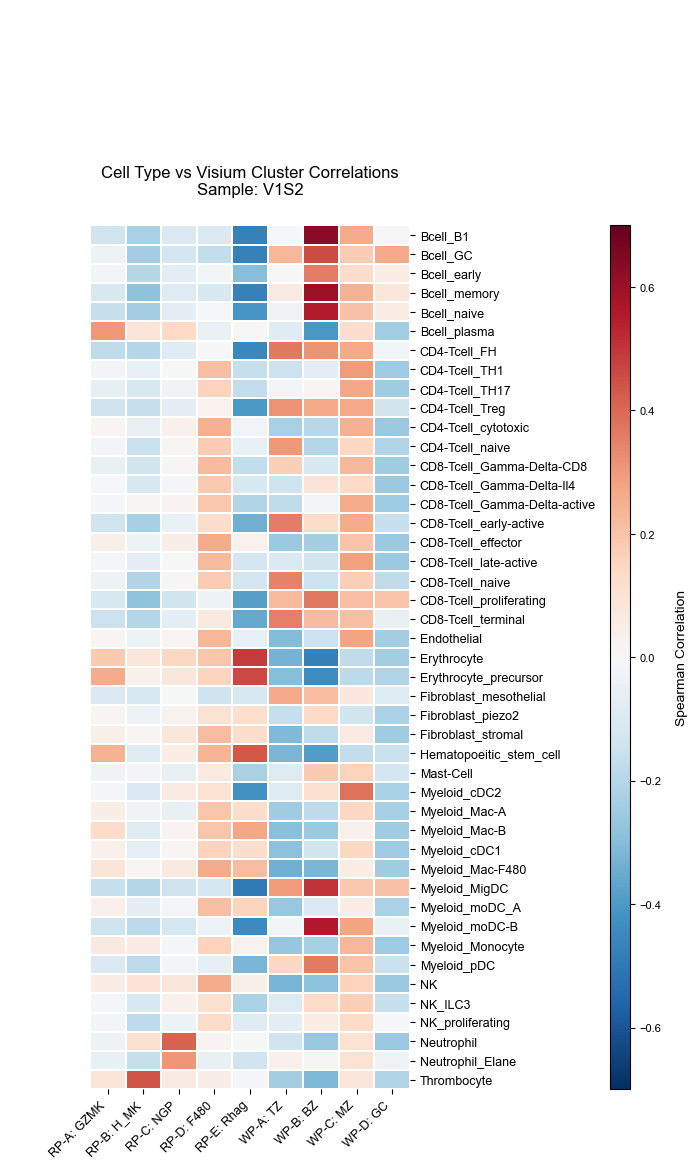

✅ Saved: compact_celltype_vs_cluster_correlations_V1S2.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S2_correlations.csv and compact_celltype_vs_cluster_correlations_V1S2_pvalues.csv

PROCESSING SAMPLE: V1S1
Data shape: (648, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ', 'WP-D: GC']
Calculating correlations for 45 cell types vs 9 clusters...
Correlation matrix shape: (45, 9)
Correlation range: [-0.538, 0.627]

Creating compact heatmap for Sample: V1S1...


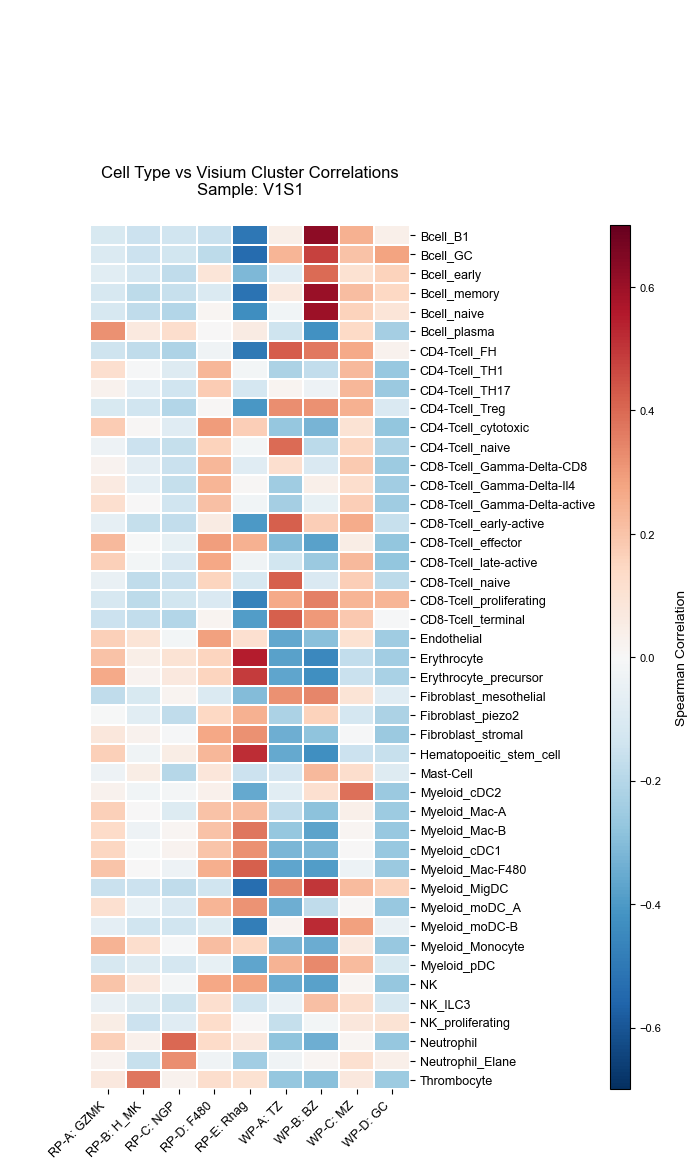

✅ Saved: compact_celltype_vs_cluster_correlations_V1S1.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S1_correlations.csv and compact_celltype_vs_cluster_correlations_V1S1_pvalues.csv

PROCESSING SAMPLE: V1S4
Data shape: (633, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.560, 0.505]

Creating compact heatmap for Sample: V1S4...


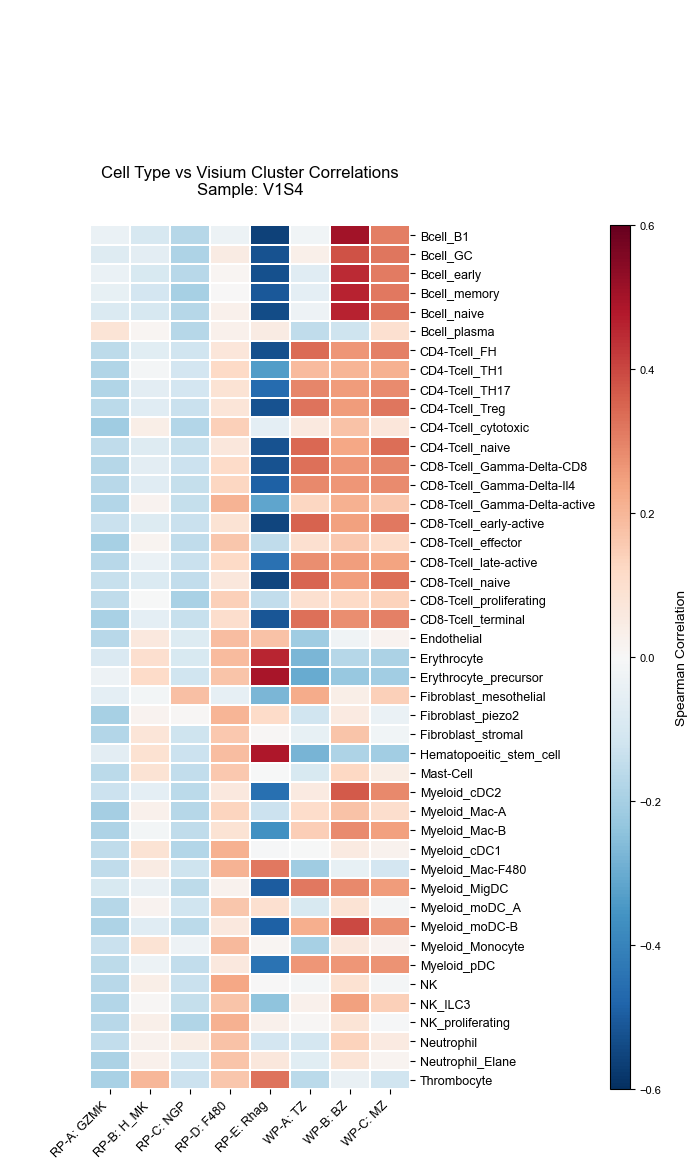

✅ Saved: compact_celltype_vs_cluster_correlations_V1S4.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S4_correlations.csv and compact_celltype_vs_cluster_correlations_V1S4_pvalues.csv

PROCESSING SAMPLE: V1S3
Data shape: (644, 45)
Available clusters: ['RP-A: GZMK', 'RP-B: H_MK', 'RP-C: NGP', 'RP-D: F480', 'RP-E: Rhag', 'WP-A: TZ', 'WP-B: BZ', 'WP-C: MZ']
Calculating correlations for 45 cell types vs 8 clusters...
Correlation matrix shape: (45, 8)
Correlation range: [-0.519, 0.508]

Creating compact heatmap for Sample: V1S3...


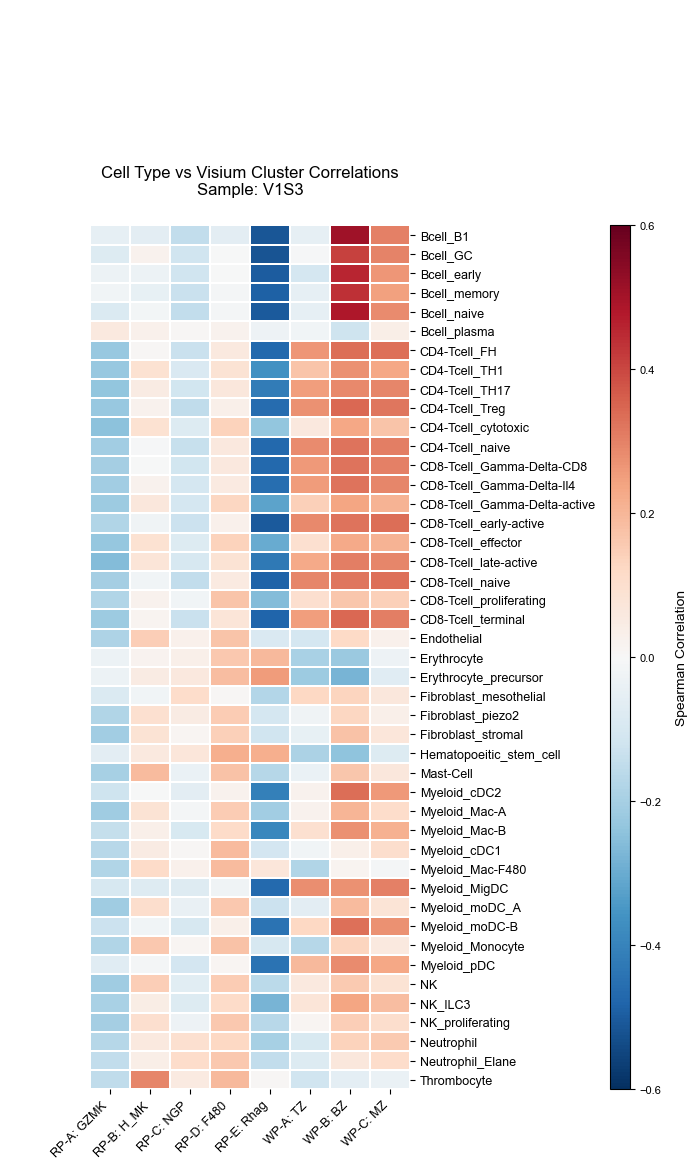

✅ Saved: compact_celltype_vs_cluster_correlations_V1S3.png and .pdf
✅ Saved: compact_celltype_vs_cluster_correlations_V1S3_correlations.csv and compact_celltype_vs_cluster_correlations_V1S3_pvalues.csv

🎉 COMPACT CORRELATION ANALYSIS COMPLETE


In [ ]:
#!/usr/bin/env python3
"""
Compact Cell Type vs Visium Cluster Correlation Heatmaps

Create compact correlation heatmaps without significance markers
"""

import pandas as pd
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import spearmanr
from scipy.cluster.hierarchy import dendrogram, linkage
import warnings

warnings.filterwarnings('ignore')

def create_compact_celltype_vs_cluster_correlations():
    """
    Create compact correlation heatmaps: Cell types vs Visium clusters
    """
    print("="*80)
    print("COMPACT CELL TYPE vs VISIUM CLUSTER CORRELATIONS")
    print("="*80)
    
    # Load data
    print("Loading data...")
    infected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_infected_072225_yk.h5ad'
    uninfected_path = '/Users/yashkulkarni/cellxgene_data/cell2location_uninfected_072225_yk.h5ad'
    
    adata_infected = sc.read_h5ad(infected_path)
    adata_uninfected = sc.read_h5ad(uninfected_path)
    
    def calculate_celltype_cluster_correlations(adata, condition_name):
        """
        Calculate correlations between cell type abundance and cluster membership
        """
        print(f"\n{'='*60}")
        print(f"PROCESSING {condition_name.upper()}")
        print(f"{'='*60}")
        
        # Get abundance data and cluster assignments
        abundance_data = adata.obsm['q05_cell_abundance_w_sf']
        cluster_assignments = adata.obs['paper_clusters'].astype(str)
        
        print(f"Data shape: {abundance_data.shape}")
        print(f"Available clusters: {sorted(cluster_assignments.unique())}")
        
        # Get cell types
        cell_types = abundance_data.columns.tolist()
        clusters = sorted(cluster_assignments.unique())
        
        # Create correlation matrix: cell_types (rows) x clusters (columns)
        correlation_matrix = np.zeros((len(cell_types), len(clusters)))
        pvalue_matrix = np.zeros((len(cell_types), len(clusters)))
        
        print(f"Calculating correlations for {len(cell_types)} cell types vs {len(clusters)} clusters...")
        
        for i, cell_type in enumerate(cell_types):
            cell_abundance = abundance_data[cell_type].values
            
            for j, cluster in enumerate(clusters):
                # Create binary indicator for cluster membership
                cluster_indicator = (cluster_assignments == cluster).astype(int)
                
                # Calculate Spearman correlation
                corr_coef, p_val = spearmanr(cell_abundance, cluster_indicator)
                correlation_matrix[i, j] = corr_coef
                pvalue_matrix[i, j] = p_val
        
        # Convert to DataFrame for easier handling
        corr_df = pd.DataFrame(
            correlation_matrix,
            index=cell_types,
            columns=clusters
        )
        
        pval_df = pd.DataFrame(
            pvalue_matrix,
            index=cell_types,
            columns=clusters
        )
        
        print(f"Correlation matrix shape: {corr_df.shape}")
        print(f"Correlation range: [{np.nanmin(correlation_matrix):.3f}, {np.nanmax(correlation_matrix):.3f}]")
        
        return corr_df, pval_df
    
    def plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename, use_clustering=True, row_order=None, col_order=None):
        """
        Create publication-quality compact clustered heatmap with colorbar at far right
        If use_clustering=False, uses provided row_order and col_order instead of dendrograms
        """
        print(f"\nCreating compact heatmap for {condition_name}...")

        # Remove any rows/columns with all NaN
        corr_df_clean = corr_df.dropna(how='all', axis=0).dropna(how='all', axis=1)

        if corr_df_clean.empty:
            print("❌ No valid correlations found!")
            return

        # If not using clustering and orders are provided, reorder the data
        if not use_clustering and row_order is not None and col_order is not None:
            # Reorder to match the provided ordering
            available_rows = [r for r in row_order if r in corr_df_clean.index]
            available_cols = [c for c in col_order if c in corr_df_clean.columns]
            corr_df_clean = corr_df_clean.loc[available_rows, available_cols]

        # Calculate dynamic vmin/vmax symmetric around 0
        max_abs = np.ceil(np.nanmax(np.abs(corr_df_clean.values)) * 10) / 10
        vmin_dyn = -max_abs
        vmax_dyn = max_abs

        # Create the clustermap with or without clustering
        g = sns.clustermap(
            corr_df_clean,
            cmap='RdBu_r',
            center=0,
            vmin=vmin_dyn,
            vmax=vmax_dyn,
            figsize=(10, 12),  # Slightly smaller for better proportions
            xticklabels=True,
            yticklabels=True,
            linewidths=0.1,
            row_cluster=use_clustering,  # Turn off clustering for individual samples
            col_cluster=use_clustering,  # Turn off clustering for individual samples
            method='average',
            metric='correlation',
            cbar_pos=None,  # No automatic colorbar
            annot=None
        )

        # COORDINATED LAYOUT: Set margins with extra space on right for colorbar
        plt.subplots_adjust(top=0.98, bottom=0.08, left=0.25, right=0.65, hspace=0, wspace=0)
        
        # Get the actual heatmap position after layout adjustment
        heatmap_pos = g.ax_heatmap.get_position()
        
        # Position colorbar at the far right edge of the figure
        cbar_left = 0.85  # Far right position
        cbar_bottom = heatmap_pos.y0      # Aligned with bottom of heatmap
        cbar_width = 0.02
        cbar_height = heatmap_pos.height  # Same height as heatmap
        
        cax = g.fig.add_axes([cbar_left, cbar_bottom, cbar_width, cbar_height])
        cbar = g.fig.colorbar(g.ax_heatmap.collections[0], cax=cax, orientation='vertical')
        cbar.set_label('Spearman Correlation', fontsize=10, labelpad=10)
        cbar.ax.tick_params(labelsize=8)

        # Title positioned relative to the heatmap center
        heatmap_center_x = heatmap_pos.x0 + heatmap_pos.width / 2
        g.fig.suptitle(f'Cell Type vs Visium Cluster Correlations\n{condition_name}', 
                       fontsize=12, x=heatmap_center_x, y=0.85, ha='center')

        # Clean, readable labels
        plt.setp(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right', fontsize=9)
        plt.setp(g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=9)

        # Save with publication quality
        plt.savefig(f'{filename}.png', dpi=300, bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.savefig(f'{filename}.pdf', bbox_inches='tight', pad_inches=0.1, facecolor='white')
        plt.show()

        print(f"✅ Saved: {filename}.png and .pdf")

        # Save data
        corr_df_clean.to_csv(f'{filename}_correlations.csv')
        pval_df.loc[corr_df_clean.index, corr_df_clean.columns].to_csv(f'{filename}_pvalues.csv')
        print(f"✅ Saved: {filename}_correlations.csv and {filename}_pvalues.csv")

        return g, corr_df_clean.index.tolist(), corr_df_clean.columns.tolist()  # Return the ordering
    
    # Process both conditions first to get the ordering
    conditions = [
        (adata_infected, "Infected Condition", "compact_celltype_vs_cluster_correlations_infected"),
        (adata_uninfected, "Uninfected Condition", "compact_celltype_vs_cluster_correlations_uninfected")
    ]
    
    # Store the ordering from the first clustered heatmap
    reference_row_order = None
    reference_col_order = None
    
    for adata, condition_name, filename in conditions:
        # Calculate correlations
        corr_df, pval_df = calculate_celltype_cluster_correlations(adata, condition_name)
        
        # Create compact heatmap with clustering
        g, row_order, col_order = plot_compact_correlation_heatmap(corr_df, pval_df, condition_name, filename, use_clustering=True)
        
        # Store the ordering from the infected condition for individual samples
        if condition_name == "Infected Condition":
            reference_row_order = row_order
            reference_col_order = col_order
    
    # Also create individual sample correlations using the reference ordering
    print(f"\n{'='*60}")
    print("INDIVIDUAL SAMPLES (Using consistent ordering)")
    print(f"{'='*60}")
    
    # Infected samples (V1S1, V1S2) - use the reference ordering, no clustering
    for sample_name in adata_infected.obs['sample'].unique():
        sample_mask = adata_infected.obs['sample'] == sample_name
        sample_adata = adata_infected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g, _, _ = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename, 
                                                 use_clustering=False, row_order=reference_row_order, col_order=reference_col_order)
    
    # Uninfected samples (V1S3, V1S4) - use the reference ordering, no clustering
    for sample_name in adata_uninfected.obs['sample'].unique():
        sample_mask = adata_uninfected.obs['sample'] == sample_name
        sample_adata = adata_uninfected[sample_mask].copy()
        
        corr_df, pval_df = calculate_celltype_cluster_correlations(sample_adata, f"Sample: {sample_name}")
        filename = f"compact_celltype_vs_cluster_correlations_{sample_name}".replace(' ', '_').replace(':', '').replace('-', '_')
        g, _, _ = plot_compact_correlation_heatmap(corr_df, pval_df, f"Sample: {sample_name}", filename, 
                                                 use_clustering=False, row_order=reference_row_order, col_order=reference_col_order)
    
    print(f"\n{'='*80}")
    print("🎉 COMPACT CORRELATION ANALYSIS COMPLETE")
    print(f"{'='*80}")

# Run the analysis
create_compact_celltype_vs_cluster_correlations()
